<a href="https://colab.research.google.com/github/RogerVin1/Assigment1-DeepLearnig/blob/main/assigment1DL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import copy, pickle, time, zipfile, urllib.request
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from scipy import ndimage
from scipy.stats import spearmanr
from skimage.draw import ellipse
from skimage.measure import regionprops
from skimage.segmentation import watershed

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## Parte 0 — Teste unitário sintético

Imagens 128×128 com 5 a 20 elipses de tamanhos variados, muitas encostadas, com ruído e contraste variáveis. A máscara de instâncias vem de graça do gerador. Serve para validar o pipeline inteiro (dados → U-Net → métricas) antes de tocar nos dados reais.

In [10]:
def gerar_amostra(size=128, min_elipses=5, max_elipses=20, raio_min=6, raio_max=20,
                  fracao_minima_visivel=0.55, rng=None):
    """Imagem sintética em tons de cinza e sua máscara de instâncias (0 = fundo, k = k-ésima elipse).
       Elipses podem se encostar; uma elipse só entra se pelo menos `fracao_minima_visivel` dela ficar visível."""
    rng = rng or np.random.default_rng()
    inst_mask = np.zeros((size, size), dtype=np.int32)
    n_elipses = int(rng.integers(min_elipses, max_elipses + 1))
    colocadas = 0

    for _ in range(12 * n_elipses):
        if colocadas == n_elipses:
            break

        cy, cx = rng.integers(raio_min, size - raio_min, size=2)
        ry, rx = rng.integers(raio_min, raio_max + 1, size=2)
        rr, cc = ellipse(cy, cx, ry, rx, shape=(size, size), rotation=rng.uniform(0, np.pi))

        candidata = np.zeros((size, size), dtype=bool)
        candidata[rr, cc] = True
        visivel = candidata & (inst_mask == 0)

        if candidata.sum() == 0 or visivel.sum() / candidata.sum() < fracao_minima_visivel:
            continue

        colocadas += 1
        inst_mask[visivel] = colocadas

    return renderizar_imagem(inst_mask, rng), inst_mask

def renderizar_imagem(inst_mask, rng):
    """Fundo escuro, um brilho por instância e ruído gaussiano, com níveis sorteados por imagem."""
    imagem = np.full(inst_mask.shape, rng.uniform(0.05, 0.20), dtype=np.float32)

    for k in range(1, inst_mask.max() + 1):
        imagem[inst_mask == k] = rng.uniform(0.45, 0.95)

    imagem += rng.normal(0, rng.uniform(0.02, 0.12), size=imagem.shape)
    return np.clip(imagem, 0, 1).astype(np.float32)

def colorir_instancias(inst_mask, rng=None):
    """Imagem RGB com uma cor aleatória por instância e fundo preto, só para visualização."""
    rng = rng or np.random.default_rng(0)
    rgb = np.zeros((*inst_mask.shape, 3), dtype=np.float32)

    for k in range(1, inst_mask.max() + 1):
        rgb[inst_mask == k] = rng.uniform(0.3, 1.0, size=3)

    return rgb

def ids_objetos(inst_mask):
    return np.unique(inst_mask[inst_mask != 0])

def n_objetos(inst_mask):
    return len(ids_objetos(inst_mask))

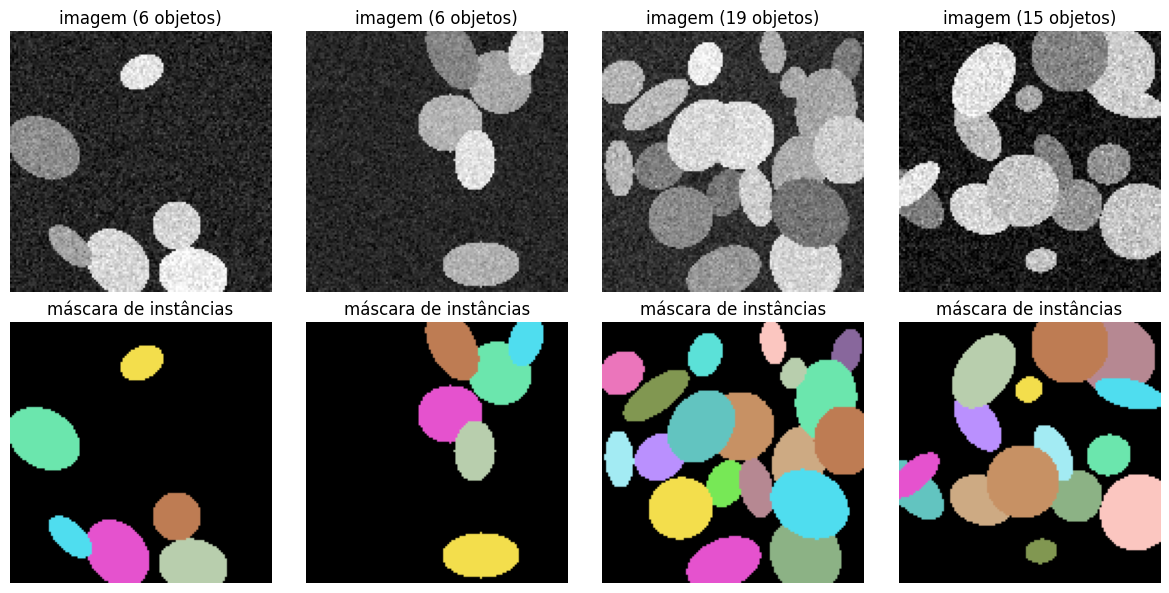

objetos por imagem (200 amostras): mín 5 | média 12.2 | máx 20


In [61]:
rng = np.random.default_rng(42)
fig, axes = plt.subplots(2, 4, figsize=(12, 6))

for col in range(4):
    imagem, inst_mask = gerar_amostra(rng=rng)
    axes[0, col].imshow(imagem, cmap="gray", vmin=0, vmax=1)
    axes[0, col].set_title(f"imagem ({n_objetos(inst_mask)} objetos)")
    axes[1, col].imshow(colorir_instancias(inst_mask))
    axes[1, col].set_title("máscara de instâncias")

for ax in axes.ravel():
    ax.axis("off")
plt.tight_layout()
plt.show()

contagens = np.array([n_objetos(gerar_amostra(rng=rng)[1]) for _ in range(200)])
print(f"objetos por imagem (200 amostras): mín {contagens.min()} | média {contagens.mean():.1f} | máx {contagens.max()}")

In [62]:
class DadosSinteticos(Dataset):
    """Pares (imagem, máscara binária) gerados na construção. Tensores (1, 128, 128)."""
    def __init__(self, n_amostras, seed):
        rng = np.random.default_rng(seed)
        self.amostras = [gerar_amostra(rng=rng) for _ in range(n_amostras)]

    def __len__(self):
        return len(self.amostras)

    def __getitem__(self, idx):
        imagem, inst_mask = self.amostras[idx]
        x = torch.from_numpy(imagem).unsqueeze(0)
        y = torch.from_numpy((inst_mask > 0).astype(np.float32)).unsqueeze(0)
        return x, y

In [14]:
def bloco_conv(c_in, c_out):
    return nn.Sequential(
        nn.Conv2d(c_in, c_out, 3, padding=1), nn.BatchNorm2d(c_out), nn.ReLU(inplace=True),
        nn.Conv2d(c_out, c_out, 3, padding=1), nn.BatchNorm2d(c_out), nn.ReLU(inplace=True),
    )

class UNetPequena(nn.Module):
    """U-Net com dois níveis de pooling e skip connections por concatenação."""
    def __init__(self, n_saidas=1):
        super().__init__()
        self.enc1 = bloco_conv(1, 16)
        self.enc2 = bloco_conv(16, 32)
        self.meio = bloco_conv(32, 64)
        self.pool = nn.MaxPool2d(2)
        self.up2 = nn.ConvTranspose2d(64, 32, 2, stride=2)
        self.dec2 = bloco_conv(64, 32)
        self.up1 = nn.ConvTranspose2d(32, 16, 2, stride=2)
        self.dec1 = bloco_conv(32, 16)
        self.saida = nn.Conv2d(16, n_saidas, 1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        m = self.meio(self.pool(e2))
        d2 = self.dec2(torch.cat([self.up2(m), e2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1))
        return self.saida(d1)

In [16]:
def dice_iou(logits, alvo, limiar=0.5):
    """Dice e IoU de cada amostra do batch (arrays numpy)."""
    pred = (torch.sigmoid(logits) > limiar).float()
    intersecao = (pred * alvo).sum(dim=(1, 2, 3))
    soma = pred.sum(dim=(1, 2, 3)) + alvo.sum(dim=(1, 2, 3))
    dice = (2 * intersecao + 1e-6) / (soma + 1e-6)
    iou = (intersecao + 1e-6) / (soma - intersecao + 1e-6)
    return dice.cpu().numpy(), iou.cpu().numpy()

def avaliar_binario(modelo, dados, batch_size=16):
    """Dice e IoU por amostra de um Dataset, na ordem do Dataset."""
    modelo.eval()
    dices, ious = [], []

    with torch.no_grad():
        for x, y in DataLoader(dados, batch_size=batch_size):
            dice, iou = dice_iou(modelo(x.to(device)), y.to(device))
            dices.append(dice)
            ious.append(iou)

    return np.concatenate(dices), np.concatenate(ious)

def metricas_binarias(modelo, val):
    dice, iou = avaliar_binario(modelo, val)
    return {"val_dice": dice.mean(), "val_iou": iou.mean()}

def treinar(modelo, treino, val, epocas, criterio, metricas, lr=1e-3, batch_size=8, augmentar=None, seed=0, verboso=True):
    """Adam + `criterio`; a cada época avalia `metricas(modelo, val)` (dict) e guarda tudo no histórico.
       O modelo fica com os pesos da época em que a primeira métrica foi máxima."""
    torch.manual_seed(seed)
    rng = np.random.default_rng(seed)
    carregador = DataLoader(treino, batch_size=batch_size, shuffle=True)
    otimizador = torch.optim.Adam(modelo.parameters(), lr=lr)
    historico = {"perda": []}
    melhor = (-np.inf, None)

    for epoca in range(epocas):
        modelo.train()
        perdas = []

        for x, y in carregador:
            if augmentar is not None:
                x, y = augmentar(x, y, rng)
            x, y = x.to(device), y.to(device)
            otimizador.zero_grad()
            perda = criterio(modelo(x), y)
            perda.backward()
            otimizador.step()
            perdas.append(perda.item())

        valores = metricas(modelo, val)
        historico["perda"].append(np.mean(perdas))
        for nome, valor in valores.items():
            historico.setdefault(nome, []).append(valor)

        principal = next(iter(valores.values()))
        if principal > melhor[0]:
            melhor = (principal, copy.deepcopy(modelo.state_dict()))

        if verboso:
            print(f"época {epoca + 1:2d} | perda {np.mean(perdas):.3f} | " + " | ".join(f"{nome} {valor:.3f}" for nome, valor in valores.items()))

    modelo.load_state_dict(melhor[1])
    return historico

In [65]:
treino_sint = DadosSinteticos(n_amostras=200, seed=1)
val_sint = DadosSinteticos(n_amostras=40, seed=2)

modelo_sint = UNetPequena().to(device)

inicio = time.time()
historico_sint = treinar(modelo_sint, treino_sint, val_sint, epocas=12, criterio=nn.BCEWithLogitsLoss(), metricas=metricas_binarias)
print(f"treinou em {time.time() - inicio:.1f}s")

época  1 | perda 0.437 | val_dice 0.917 | val_iou 0.849
época  2 | perda 0.314 | val_dice 0.982 | val_iou 0.965
época  3 | perda 0.252 | val_dice 0.993 | val_iou 0.985
época  4 | perda 0.201 | val_dice 0.997 | val_iou 0.994
época  5 | perda 0.162 | val_dice 0.999 | val_iou 0.997
época  6 | perda 0.127 | val_dice 0.999 | val_iou 0.998
época  7 | perda 0.103 | val_dice 0.999 | val_iou 0.999
época  8 | perda 0.084 | val_dice 0.999 | val_iou 0.999
época  9 | perda 0.077 | val_dice 0.994 | val_iou 0.989
época 10 | perda 0.062 | val_dice 0.999 | val_iou 0.998
época 11 | perda 0.051 | val_dice 0.999 | val_iou 0.999
época 12 | perda 0.045 | val_dice 0.999 | val_iou 0.999
treinou em 2.6s


**Métrica do teste unitário.** A U-Net pequena converge em poucas épocas e bem abaixo dos 5 minutos exigidos; o Dice e o IoU de validação abaixo são a métrica reportada para a Parte 0.

In [66]:
dice_val, iou_val = avaliar_binario(modelo_sint, val_sint)
print("=== Métrica do teste unitário (Parte 0) ===")
print(f"Dice (val): {dice_val.mean():.4f}")
print(f"IoU  (val): {iou_val.mean():.4f}")

=== Métrica do teste unitário (Parte 0) ===
Dice (val): 0.9994
IoU  (val): 0.9988


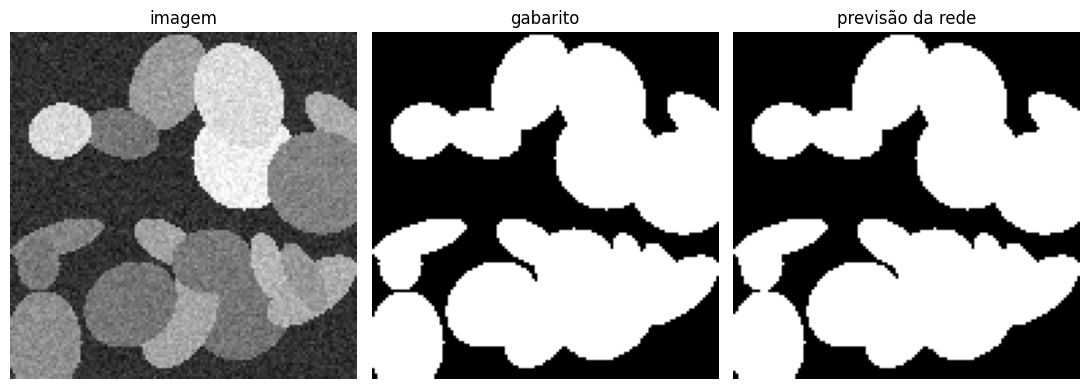

In [67]:
x, y = val_sint[0]
with torch.no_grad():
    prob = torch.sigmoid(modelo_sint(x.unsqueeze(0).to(device)))[0, 0].cpu().numpy()

fig, ax = plt.subplots(1, 3, figsize=(11, 4))
for a, imagem, titulo in zip(ax, [x[0], y[0], prob > 0.5], ["imagem", "gabarito", "previsão da rede"]):
    a.imshow(imagem, cmap="gray")
    a.set_title(titulo)
    a.axis("off")
plt.tight_layout()
plt.show()

## Dados reais — BBBC038 (DSB2018, `stage1_train`)

- **Instâncias**: os PNGs de `masks/` viram um mapa de instâncias no mesmo formato do gerador sintético (0 = fundo, k = k-ésimo núcleo).
- **Mesma entrada do sintético**: 1 canal em [0,1], núcleos claros sobre fundo escuro. Imagens de fundo claro (histologia H&E, campo claro) são invertidas; a decisão usa só a mediana da imagem, não a máscara, então vale também na inferência.
- **Modalidade** por heurística de cor e brilho do fundo: `fluorescencia` (cinza, fundo escuro), `histologia` (colorida), `campo_claro` (cinza, fundo claro).
- **Split treino/val/teste estratificado por modalidade** (70/15/15, seed fixa). Campo claro tem só ~18 imagens: sem estratificar, o teste poderia não ter nenhuma. A divisão é por imagem, antes de recortar, para que recortes da mesma imagem nunca caiam em splits diferentes.
- `DadosReais` tem a mesma interface de `DadosSinteticos` (recortes 128×128, `(x, y)` binário) e guarda o mapa de instâncias de cada recorte em `.instancias`.

In [5]:
RAIZ_DADOS = Path("data/BBBC038")
URL_TREINO = "https://data.broadinstitute.org/bbbc/BBBC038/stage1_train.zip"

def baixar_bbbc038(raiz=RAIZ_DADOS, url=URL_TREINO):
    pasta = raiz / "stage1_train"
    if pasta.exists() and any(pasta.iterdir()):
        return pasta

    raiz.mkdir(parents=True, exist_ok=True)
    arquivo_zip = raiz / "stage1_train.zip"
    if not arquivo_zip.exists():
        print("baixando", url)
        urllib.request.urlretrieve(url, arquivo_zip)

    with zipfile.ZipFile(arquivo_zip) as z:
        z.extractall(pasta)

    return pasta

In [6]:
def carregar_imagem_bbbc(pasta_imagem):
    """Devolve (rgb em [0,1], mapa de instâncias) de uma pasta <ImageId>/ do BBBC038."""
    arquivo = next((pasta_imagem / "images").glob("*.png"))
    rgb = np.asarray(Image.open(arquivo).convert("RGB")).astype(np.float32) / 255

    inst_mask = np.zeros(rgb.shape[:2], dtype=np.int32)
    for k, arquivo_mascara in enumerate(sorted((pasta_imagem / "masks").glob("*.png")), start=1):
        mascara = np.asarray(Image.open(arquivo_mascara).convert("L")) > 0
        inst_mask[mascara & (inst_mask == 0)] = k

    return rgb, inst_mask

def modalidade(rgb):
    """A mediana da imagem é o fundo (que domina a área); a saturação separa histologia das demais."""
    saturacao = (rgb.max(axis=2) - rgb.min(axis=2)).mean()
    fundo = np.median(rgb.mean(axis=2))

    if saturacao > 0.05:
        return "histologia"
    if fundo > 0.5:
        return "campo_claro"
    return "fluorescencia"

def para_cinza(rgb):
    """Cinza em [0,1] com núcleos claros sobre fundo escuro: inverte se o fundo (mediana) é claro
       e estica o contraste entre os percentis 1 e 99."""
    cinza = rgb.mean(axis=2)
    if np.median(cinza) > 0.5:
        cinza = 1 - cinza

    p1, p99 = np.percentile(cinza, [1, 99])
    if p99 - p1 > 1e-3:
        cinza = (cinza - p1) / (p99 - p1)

    return np.clip(cinza, 0, 1).astype(np.float32)

In [7]:
def carregar_bbbc038(pasta, cache=RAIZ_DADOS / "stage1_train_cache.pkl"):
    """Lista de dicts {id, imagem uint8 (já em cinza normalizado), inst int16, modalidade}.
       uint8/int16 mantêm o cache em ~300 MB; a leitura dos ~29 mil PNGs só acontece uma vez."""
    if cache.exists():
        return pickle.load(open(cache, "rb"))

    pastas = sorted(p for p in pasta.iterdir() if (p / "images").is_dir())
    itens = []

    for i, pasta_imagem in enumerate(pastas, start=1):
        rgb, inst_mask = carregar_imagem_bbbc(pasta_imagem)
        itens.append({"id": pasta_imagem.name,
                      "imagem": np.round(para_cinza(rgb) * 255).astype(np.uint8),
                      "inst": inst_mask.astype(np.int16),
                      "modalidade": modalidade(rgb)})
        if i % 100 == 0:
            print(f"  {i}/{len(pastas)} imagens lidas")

    pickle.dump(itens, open(cache, "wb"))
    return itens

itens_bbbc = carregar_bbbc038(baixar_bbbc038())

modalidades, contagens = np.unique([item["modalidade"] for item in itens_bbbc], return_counts=True)
print(f"{len(itens_bbbc)} imagens |", dict(zip(modalidades.tolist(), contagens.tolist())))

670 imagens | {'campo_claro': 18, 'fluorescencia': 546, 'histologia': 106}


In [8]:
def split_estratificado(itens, fracoes=(0.70, 0.15, 0.15), seed=0):
    """Embaralha e divide cada modalidade separadamente, na mesma proporção."""
    rng = np.random.default_rng(seed)
    por_modalidade = {}
    for i, item in enumerate(itens):
        por_modalidade.setdefault(item["modalidade"], []).append(i)

    treino, val, teste = [], [], []
    for indices in por_modalidade.values():
        indices = rng.permutation(indices)
        n_treino = round(fracoes[0] * len(indices))
        n_val = round(fracoes[1] * len(indices))
        treino += indices[:n_treino].tolist()
        val += indices[n_treino:n_treino + n_val].tolist()
        teste += indices[n_treino + n_val:].tolist()

    return treino, val, teste

idx_treino, idx_val, idx_teste = split_estratificado(itens_bbbc)

def contar(indices, modalidade):
    return sum(itens_bbbc[i]["modalidade"] == modalidade for i in indices)

print(f"{'modalidade':15s} | treino | val | teste")
for mod in modalidades:
    print(f"{mod:15s} | {contar(idx_treino, mod):6d} | {contar(idx_val, mod):3d} | {contar(idx_teste, mod):5d}")
print(f"{'total':15s} | {len(idx_treino):6d} | {len(idx_val):3d} | {len(idx_teste):5d}")

modalidade      | treino | val | teste
campo_claro     |     13 |   3 |     2
fluorescencia   |    382 |  82 |    82
histologia      |     74 |  16 |    16
total           |    469 | 101 |   100


In [19]:
def recorte_aleatorio(imagem, inst_mask, size, rng, tentativas=5):
    """Recorte size×size em posição aleatória; tenta algumas vezes até conter pelo menos um núcleo."""
    imagem = imagem.astype(np.float32) / 255
    inst_mask = inst_mask.astype(np.int32)
    altura, largura = imagem.shape

    for _ in range(tentativas):
        y0 = rng.integers(0, altura - size + 1)
        x0 = rng.integers(0, largura - size + 1)
        recorte_inst = inst_mask[y0:y0 + size, x0:x0 + size]
        if recorte_inst.any():
            break

    return imagem[y0:y0 + size, x0:x0 + size].copy(), recorte_inst.copy()

class DadosReais(Dataset):
    """Recortes 128×128 do BBBC038 com a mesma interface de DadosSinteticos.
       `.instancias[i]` e `.modalidades[i]` acompanham cada recorte; `.amostra(i)` devolve (imagem, inst_mask) em numpy."""
    def __init__(self, itens, indices, recortes_por_imagem, size=128, seed=0):
        rng = np.random.default_rng(seed)
        self.imagens, self.instancias, self.modalidades = [], [], []

        for i in indices:
            for _ in range(recortes_por_imagem):
                imagem, inst_mask = recorte_aleatorio(itens[i]["imagem"], itens[i]["inst"], size, rng)
                self.imagens.append(imagem)
                self.instancias.append(inst_mask)
                self.modalidades.append(itens[i]["modalidade"])

    def __len__(self):
        return len(self.imagens)

    def __getitem__(self, idx):
        x = torch.from_numpy(self.imagens[idx]).unsqueeze(0)
        y = torch.from_numpy((self.instancias[idx] > 0).astype(np.float32)).unsqueeze(0)
        return x, y

    def amostra(self, idx):
        return self.imagens[idx], self.instancias[idx]

treino_real = DadosReais(itens_bbbc, idx_treino, recortes_por_imagem=4, seed=1)
val_real = DadosReais(itens_bbbc, idx_val, recortes_por_imagem=2, seed=2)
teste_real = DadosReais(itens_bbbc, idx_teste, recortes_por_imagem=2, seed=3)
print(f"recortes 128×128 -> treino {len(treino_real)} | val {len(val_real)} | teste {len(teste_real)}")

recortes 128×128 -> treino 1876 | val 202 | teste 200


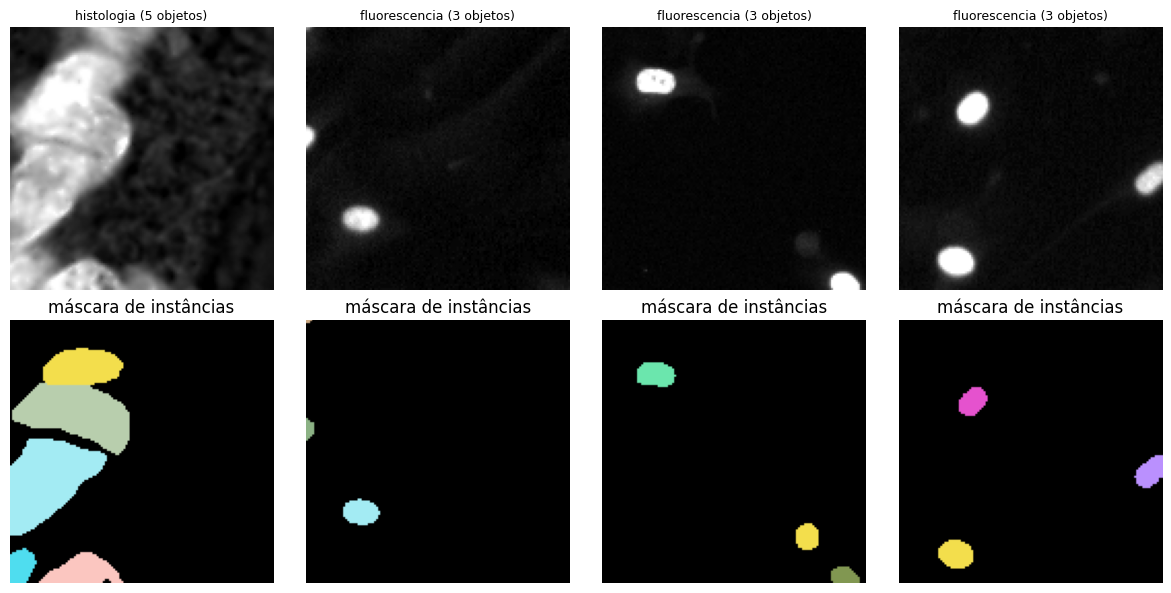

objetos por recorte: mín 0 | média 7.9 | máx 45


In [73]:
rng = np.random.default_rng(0)
fig, axes = plt.subplots(2, 4, figsize=(12, 6))

for col in range(4):
    k = rng.integers(len(treino_real))
    imagem, inst_mask = treino_real.amostra(k)
    axes[0, col].imshow(imagem, cmap="gray", vmin=0, vmax=1)
    axes[0, col].set_title(f"{treino_real.modalidades[k]} ({n_objetos(inst_mask)} objetos)", fontsize=9)
    axes[1, col].imshow(colorir_instancias(inst_mask))
    axes[1, col].set_title("máscara de instâncias")

for ax in axes.ravel():
    ax.axis("off")
plt.tight_layout()
plt.show()

contagens = np.array([n_objetos(inst_mask) for inst_mask in treino_real.instancias])
print(f"objetos por recorte: mín {contagens.min()} | média {contagens.mean():.1f} | máx {contagens.max()}")

## Parte 1 — Baseline de segmentação semântica

Mesmo pipeline da Parte 0, agora no BBBC038, seguindo os cinco itens do enunciado:

1. U-Net binária (fundo vs. núcleo), reportando **IoU e Dice**;
2. instâncias pelo método **ingênuo** (limiar + componentes conexos);
3. avaliação **como instâncias**: mAP em IoU de 0,50 a 0,95 e **erro absoluto de contagem**;
4. **regra de matching** documentada;
5. mAP e erro de contagem em função da **densidade** de objetos.

O treino ajusta os pesos, a validação escolhe a época e todos os números reportados são do teste.

### 1.1 U-Net binária

Mesma `UNetPequena`, BCE e Adam da Parte 0. Duas diferenças: flips horizontais/verticais como augmentation (núcleos não têm orientação preferida) e mais épocas, porque os dados reais são bem mais variados. Os pesos usados daqui em diante são os da melhor época na validação.

In [30]:
def flip_aleatorio(x, y, rng):
    """O mesmo flip (horizontal e/ou vertical) na imagem e na máscara."""
    if rng.random() < 0.5:
        x, y = x.flip(-1), y.flip(-1)
    if rng.random() < 0.5:
        x, y = x.flip(-2), y.flip(-2)
    return x, y

modelo_real = UNetPequena().to(device)

inicio = time.time()
historico_real = treinar(modelo_real, treino_real, val_real, epocas=20, criterio=nn.BCEWithLogitsLoss(),
                         metricas=metricas_binarias, augmentar=flip_aleatorio)
print(f"treinou em {time.time() - inicio:.1f}s")

época  1 | perda 0.382 | val_dice 0.850 | val_iou 0.767
época  2 | perda 0.157 | val_dice 0.861 | val_iou 0.782
época  3 | perda 0.115 | val_dice 0.875 | val_iou 0.802
época  4 | perda 0.100 | val_dice 0.864 | val_iou 0.784
época  5 | perda 0.094 | val_dice 0.872 | val_iou 0.794
época  6 | perda 0.092 | val_dice 0.874 | val_iou 0.798
época  7 | perda 0.086 | val_dice 0.882 | val_iou 0.813
época  8 | perda 0.088 | val_dice 0.880 | val_iou 0.808
época  9 | perda 0.084 | val_dice 0.878 | val_iou 0.808
época 10 | perda 0.082 | val_dice 0.879 | val_iou 0.809
época 11 | perda 0.081 | val_dice 0.880 | val_iou 0.809
época 12 | perda 0.080 | val_dice 0.881 | val_iou 0.812
época 13 | perda 0.077 | val_dice 0.880 | val_iou 0.810
época 14 | perda 0.075 | val_dice 0.875 | val_iou 0.806
época 15 | perda 0.076 | val_dice 0.881 | val_iou 0.812
época 16 | perda 0.079 | val_dice 0.875 | val_iou 0.804
época 17 | perda 0.074 | val_dice 0.879 | val_iou 0.809
época 18 | perda 0.073 | val_dice 0.883 | val_io

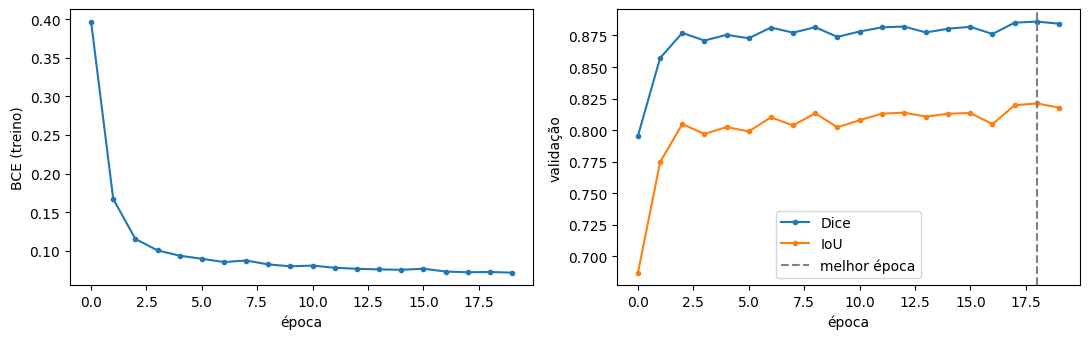

In [75]:
melhor_epoca = int(np.argmax(historico_real["val_dice"]))

fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
ax[0].plot(historico_real["perda"], "-o", ms=3)
ax[0].set_xlabel("época")
ax[0].set_ylabel("BCE (treino)")
ax[1].plot(historico_real["val_dice"], "-o", ms=3, label="Dice")
ax[1].plot(historico_real["val_iou"], "-o", ms=3, label="IoU")
ax[1].axvline(melhor_epoca, ls="--", color="gray", label="melhor época")
ax[1].set_xlabel("época")
ax[1].set_ylabel("validação")
ax[1].legend()
plt.tight_layout()
plt.show()

**Métrica semântica no teste.** Dice e IoU médios por recorte, no total e por modalidade. A quebra por modalidade é o motivo do split estratificado: a média global esconderia um resultado ruim em campo claro, que tem só 2 imagens no teste.

In [76]:
dice_teste, iou_teste = avaliar_binario(modelo_real, teste_real)
modalidades_teste = np.array(teste_real.modalidades)

print("=== Segmentação binária no teste (BBBC038) ===")
print(f"{'modalidade':15s} | n   | Dice  | IoU")
for mod in modalidades:
    sel = modalidades_teste == mod
    print(f"{mod:15s} | {sel.sum():3d} | {dice_teste[sel].mean():.3f} | {iou_teste[sel].mean():.3f}")
print(f"{'total':15s} | {len(teste_real):3d} | {dice_teste.mean():.3f} | {iou_teste.mean():.3f}")

Path("checkpoints").mkdir(exist_ok=True)
torch.save(modelo_real.state_dict(), "checkpoints/unet_binaria_bbbc038.pt")

=== Segmentação binária no teste (BBBC038) ===
modalidade      | n   | Dice  | IoU
campo_claro     |   4 | 0.448 | 0.326
fluorescencia   | 164 | 0.897 | 0.834
histologia      |  32 | 0.851 | 0.759
total           | 200 | 0.880 | 0.812


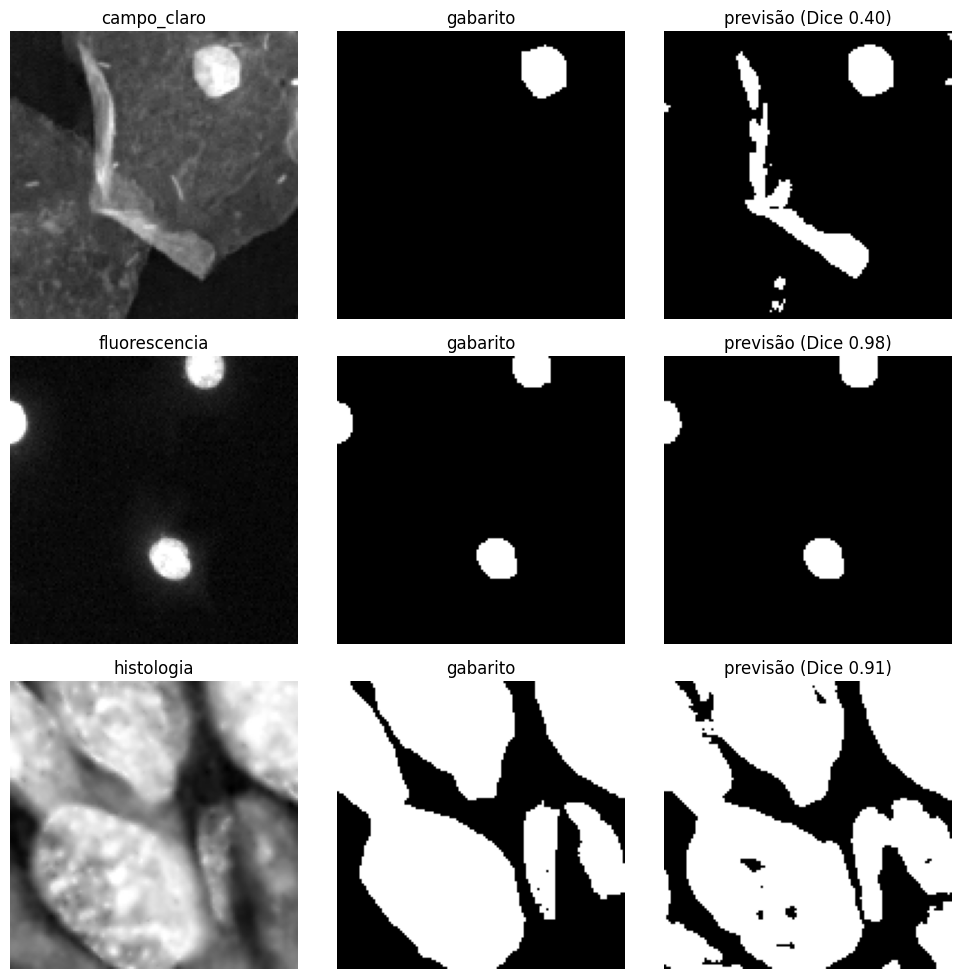

In [77]:
exemplos = [int(np.argmax(modalidades_teste == mod)) for mod in modalidades]

fig, axes = plt.subplots(len(exemplos), 3, figsize=(10, 3.3 * len(exemplos)))
for ax, k in zip(axes, exemplos):
    x, y = teste_real[k]
    with torch.no_grad():
        prob = torch.sigmoid(modelo_real(x.unsqueeze(0).to(device)))[0, 0].cpu().numpy()

    ax[0].imshow(x[0], cmap="gray", vmin=0, vmax=1)
    ax[0].set_title(modalidades_teste[k])
    ax[1].imshow(y[0], cmap="gray")
    ax[1].set_title("gabarito")
    ax[2].imshow(prob > 0.5, cmap="gray")
    ax[2].set_title(f"previsão (Dice {dice_teste[k]:.2f})")

for ax in axes.ravel():
    ax.axis("off")
plt.tight_layout()
plt.show()

### 1.2 Instâncias pelo método ingênuo

Binariza a probabilidade em 0,5 e chama de objeto cada componente conexo (`ndimage.label`, conectividade 4). Dois núcleos encostados viram uma mancha só — e no BBBC038 núcleos encostados são a regra.

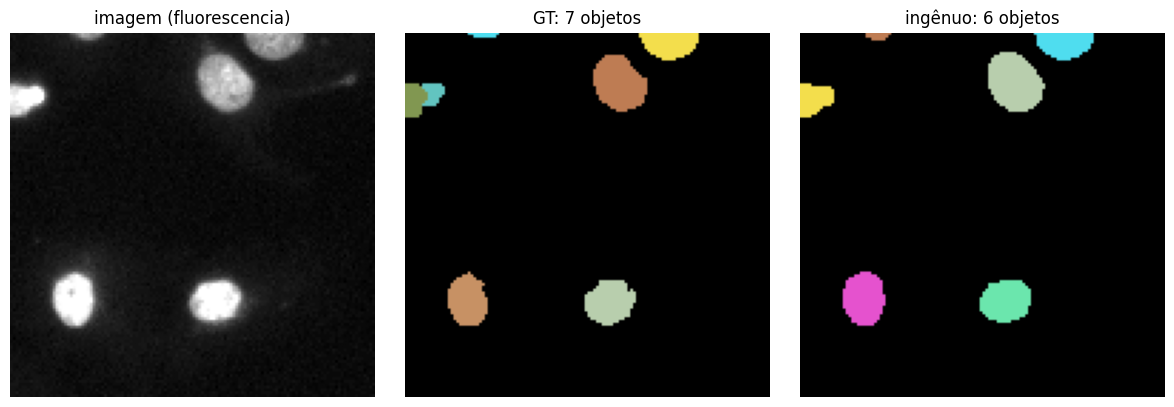

In [33]:
def instancias_ingenuas(prob, limiar=0.5):
    rotulos, _ = ndimage.label(prob > limiar)
    return rotulos.astype(np.int32)

def prever_prob(modelo, imagem):
    modelo.eval()
    x = torch.from_numpy(imagem)[None, None].to(device)
    with torch.no_grad():
        return torch.sigmoid(modelo(x))[0, 0].cpu().numpy()

def segmentar_ingenuo(imagem):
    return instancias_ingenuas(prever_prob(modelo_real, imagem))

k = 7
imagem, gt_labels = teste_real.amostra(k)
pred_labels = segmentar_ingenuo(imagem)

fig, ax = plt.subplots(1, 3, figsize=(12, 4))
ax[0].imshow(imagem, cmap="gray", vmin=0, vmax=1)
ax[0].set_title(f"imagem ({teste_real.modalidades[k]})")
ax[1].imshow(colorir_instancias(gt_labels))
ax[1].set_title(f"GT: {n_objetos(gt_labels)} objetos")
ax[2].imshow(colorir_instancias(pred_labels))
ax[2].set_title(f"ingênuo: {n_objetos(pred_labels)} objetos")
for a in ax:
    a.axis("off")
plt.tight_layout()
plt.show()

### 1.3 – 1.4 Avaliação como instâncias e regra de matching

O AP do slide 6 é por classe (métrica semântica). Aqui o matching é feito à mão, no nível de instância:

1. **Matriz de IoU** entre cada objeto previsto e cada objeto verdadeiro (só pares que se tocam têm IoU > 0).
2. **Matching guloso por IoU decrescente**: para um limiar $t$, os pares com IoU $\ge t$ são percorridos do maior para o menor IoU e cada objeto (previsto ou verdadeiro) entra em no máximo um par. Pares casados são TP; previstos que sobraram, FP; verdadeiros sem par, FN. Escolhemos o guloso, e não o Hungarian, porque é o que a métrica oficial do DSB2018 usa e porque com IoU $\ge 0{,}5$ um objeto previsto raramente tem mais de um candidato — na prática os dois coincidem.
3. $\mathrm{AP}_t = TP / (TP + FP + FN)$, a definição do DSB2018.
4. **mAP** = média de $\mathrm{AP}_t$ em $t \in \{0{,}50, 0{,}55, \dots, 0{,}95\}$, por imagem, depois média sobre as imagens.
5. **Erro absoluto de contagem** = $|\#\text{previstos} - \#\text{verdadeiros}|$ por imagem.

Núcleos fundidos pelo ingênuo contam uma vez como TP (se o IoU com o maior deles passar do limiar) e os demais viram FN — é assim que o fracasso da baseline aparece no número.

In [26]:
LIMIARES_IOU = np.arange(0.5, 1.0, 0.05)

def matriz_iou(pred_labels, gt_labels):
    """IoU[i, j] entre o i-ésimo objeto previsto e o j-ésimo verdadeiro."""
    ids_pred = np.unique(pred_labels[pred_labels != 0])
    ids_gt = np.unique(gt_labels[gt_labels != 0])
    iou = np.zeros((len(ids_pred), len(ids_gt)), dtype=np.float32)
    coluna = {j: c for c, j in enumerate(ids_gt)}

    for linha, i in enumerate(ids_pred):
        objeto = pred_labels == i
        vizinhos = np.unique(gt_labels[objeto])
        for j in vizinhos[vizinhos != 0]:
            intersecao = np.logical_and(objeto, gt_labels == j).sum()
            uniao = objeto.sum() + (gt_labels == j).sum() - intersecao
            iou[linha, coluna[j]] = intersecao / uniao

    return iou

def matching_guloso(iou, limiar):
    """Casa os pares de maior IoU primeiro, cada objeto no máximo uma vez. Devolve (TP, FP, FN)."""
    n_pred, n_gt = iou.shape
    pares = sorted(((iou[i, j], i, j) for i in range(n_pred) for j in range(n_gt) if iou[i, j] >= limiar), reverse=True)
    usados_pred, usados_gt = set(), set()

    for _, i, j in pares:
        if i not in usados_pred and j not in usados_gt:
            usados_pred.add(i)
            usados_gt.add(j)

    tp = len(usados_pred)
    return tp, n_pred - tp, n_gt - tp

def aps_de_uma_imagem(pred_labels, gt_labels):
    """AP em cada limiar de IoU para um par (previsão, gabarito)."""
    iou = matriz_iou(pred_labels, gt_labels)
    aps = []
    for limiar in LIMIARES_IOU:
        tp, fp, fn = matching_guloso(iou, limiar)
        aps.append(tp / (tp + fp + fn) if tp + fp + fn > 0 else 0.0)
    return np.array(aps)

In [34]:
def avaliar_instancias(segmentar, dados):
    """mAP, erro de contagem e densidade por recorte. `segmentar(imagem) -> labels` é rede + pós-processamento."""
    resultado = {"aps": [], "densidades": [], "erros": []}

    for k in range(len(dados)):
        imagem, gt_labels = dados.amostra(k)
        pred_labels = segmentar(imagem)
        resultado["aps"].append(aps_de_uma_imagem(pred_labels, gt_labels))
        resultado["densidades"].append(n_objetos(gt_labels))
        resultado["erros"].append(abs(n_objetos(pred_labels) - n_objetos(gt_labels)))

    resultado = {chave: np.array(valor) for chave, valor in resultado.items()}
    resultado["maps"] = resultado["aps"].mean(axis=1)
    resultado["mAP"] = resultado["maps"].mean()
    resultado["erro_contagem_medio"] = resultado["erros"].mean()
    resultado["modalidades"] = np.array(dados.modalidades)
    return resultado

res_ingenuo = avaliar_instancias(segmentar_ingenuo, teste_real)

print("=== Baseline ingênua como instâncias (teste, BBBC038) ===")
print(f"mAP (IoU 0.50 a 0.95): {res_ingenuo['mAP']:.3f}")
print(f"erro absoluto de contagem por recorte: {res_ingenuo['erro_contagem_medio']:.2f}\n")

print("AP por limiar de IoU:")
for limiar, ap in zip(LIMIARES_IOU, res_ingenuo["aps"].mean(axis=0)):
    print(f"  IoU >= {limiar:.2f}: {ap:.3f}")

print(f"\n{'modalidade':15s} | n   | mAP   | erro de contagem")
for mod in modalidades:
    sel = res_ingenuo["modalidades"] == mod
    print(f"{mod:15s} | {sel.sum():3d} | {res_ingenuo['maps'][sel].mean():.3f} | {res_ingenuo['erros'][sel].mean():.2f}")

=== Baseline ingênua como instâncias (teste, BBBC038) ===
mAP (IoU 0.50 a 0.95): 0.477
erro absoluto de contagem por recorte: 2.20

AP por limiar de IoU:
  IoU >= 0.50: 0.679
  IoU >= 0.55: 0.644
  IoU >= 0.60: 0.609
  IoU >= 0.65: 0.588
  IoU >= 0.70: 0.551
  IoU >= 0.75: 0.505
  IoU >= 0.80: 0.453
  IoU >= 0.85: 0.363
  IoU >= 0.90: 0.263
  IoU >= 0.95: 0.114

modalidade      | n   | mAP   | erro de contagem
campo_claro     |   4 | 0.113 | 6.75
fluorescencia   | 164 | 0.533 | 1.65
histologia      |  32 | 0.235 | 4.47


### 1.5 Quantificando o fracasso: métricas em função da densidade

Densidade = número de núcleos verdadeiros no recorte. A distribuição é assimétrica (muitos recortes com poucos núcleos, alguns com dezenas), então as faixas são quantis, para que cada ponto da curva média tenha o mesmo número de recortes. Quanto mais núcleos, mais eles se encostam e mais o ingênuo funde objetos: o mAP deve cair e o erro de contagem crescer.

ingênuo    | Spearman(densidade, mAP) = -0.267 | Spearman(densidade, erro) = +0.516


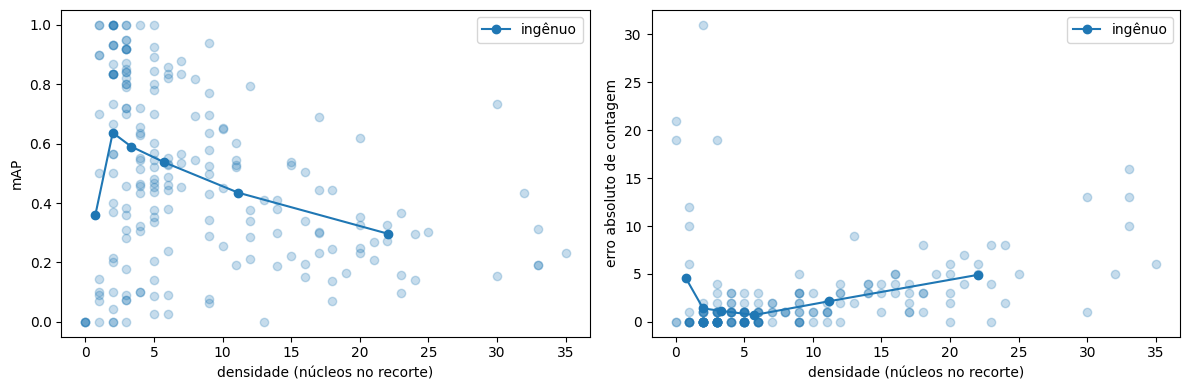

In [81]:
def plotar_por_densidade(resultados):
    """mAP e erro de contagem de cada recorte contra a densidade, com a média por faixa de quantis; uma curva por método."""
    densidades = next(iter(resultados.values()))["densidades"]
    bordas = np.unique(np.quantile(densidades, np.linspace(0, 1, 7)))
    faixa = np.clip(np.digitize(densidades, bordas) - 1, 0, len(bordas) - 2)
    faixas = [faixa == f for f in range(len(bordas) - 1) if (faixa == f).any()]
    centros = [densidades[sel].mean() for sel in faixas]
    cores = plt.rcParams["axes.prop_cycle"].by_key()["color"]

    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    for cor, (nome, res) in zip(cores, resultados.items()):
        for a, chave in zip(ax, ["maps", "erros"]):
            a.scatter(densidades, res[chave], color=cor, alpha=0.25)
            a.plot(centros, [res[chave][sel].mean() for sel in faixas], "-o", color=cor, label=nome)
        print(f"{nome:10s} | Spearman(densidade, mAP) = {spearmanr(densidades, res['maps']).statistic:+.3f}"
              f" | Spearman(densidade, erro) = {spearmanr(densidades, res['erros']).statistic:+.3f}")

    ax[0].set_ylabel("mAP")
    ax[1].set_ylabel("erro absoluto de contagem")
    for a in ax:
        a.set_xlabel("densidade (núcleos no recorte)")
        a.legend()
    plt.tight_layout()
    plt.show()

plotar_por_densidade({"ingênuo": res_ingenuo})

**O que a Parte 1 mostra.** A segmentação semântica funciona: a rede sabe onde há núcleo. O problema está só na decodificação em instâncias — o ingênuo funde núcleos encostados, o AP despenca nos limiares altos de IoU e o erro de contagem cresce com a densidade. É isso que a cabeça de instâncias da Parte 2 precisa resolver, com o mesmo encoder-decoder e as mesmas métricas: `avaliar_instancias` recebe qualquer `segmentar(imagem) -> labels`, então a comparação é direta.

## Parte 2 — Cabeça de instâncias: Trilha A (fronteiras + watershed)

Na Parte 1 a rede acerta *onde* há núcleo, mas "núcleo" é a mesma classe dos dois lados de um contato, então limiar + componentes conexos funde vizinhos. O encoder-decoder fica o mesmo; muda **o que ele prevê**: três classes, fundo / interior / fronteira. Interiores de núcleos vizinhos nunca se tocam por construção, então cada componente conexo de interior é um marcador, e o watershed cresce os marcadores sobre o foreground.

As três decisões pedidas no enunciado — como gerar o rótulo e com que espessura, como pesar a classe fronteira, como decodificar — estão em 2.1 a 2.3; 2.4 compara com a baseline nas mesmas métricas.

### 2.1 Representação: rótulo de 3 classes a partir das máscaras individuais

Cada máscara individual é erodida em `espessura` pixels: o que sobra é **interior** (1), o anel removido é **fronteira** (2). O anel envolve o núcleo inteiro, não só o trecho em contato com outro núcleo — é mais simples, dá mais pixels à classe minoritária, e o que importa para o watershed (interiores de vizinhos separados) vale do mesmo jeito.

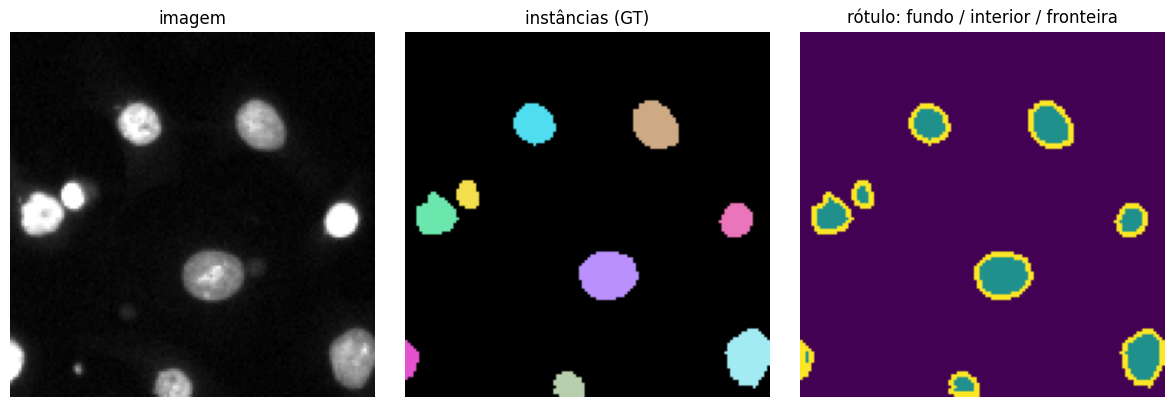

In [23]:
def rotulo_3classes(inst_mask, espessura):
    classes = np.zeros(inst_mask.shape, dtype=np.int64)
    for k in ids_objetos(inst_mask):
        nucleo = inst_mask == k
        classes[nucleo] = 2
        classes[ndimage.binary_erosion(nucleo, iterations=espessura)] = 1
    return classes

imagem, inst_mask = treino_real.amostra(0)

fig, ax = plt.subplots(1, 3, figsize=(12, 4))
ax[0].imshow(imagem, cmap="gray", vmin=0, vmax=1)
ax[0].set_title("imagem")
ax[1].imshow(colorir_instancias(inst_mask))
ax[1].set_title("instâncias (GT)")
ax[2].imshow(rotulo_3classes(inst_mask, espessura=2), cmap="viridis", vmin=0, vmax=2)
ax[2].set_title("rótulo: fundo / interior / fronteira")
for a in ax:
    a.axis("off")
plt.tight_layout()
plt.show()

### 2.2 Decodificação por watershed

Marcadores = componentes conexos do interior previsto; máscara = interior ∪ fronteira; relevo = −distância ao fundo. Cada pixel de fronteira vai para a bacia do marcador mais próximo.

A mesma decodificação aplicada ao **rótulo verdadeiro** dá o teto da representação: o mAP que uma rede perfeita alcançaria. O teto mede só o custo do anel — quanto mais grosso, mais pixels o watershed precisa reatribuir e mais núcleos pequenos perdem o interior (ficam sem marcador e desaparecem). O benefício de um anel mais grosso, ser mais fácil de prever e separar vizinhos mesmo com erro da rede, só aparece treinando. Ficamos com 2 px como compromisso; a espessura é um eixo natural de ablação para a Parte 3.

In [27]:
def decodificar_watershed(classes):
    interior = classes == 1
    foreground = classes >= 1
    marcadores, _ = ndimage.label(interior)
    relevo = -ndimage.distance_transform_edt(foreground)
    return watershed(relevo, markers=marcadores, mask=foreground).astype(np.int32)

print("espessura | mAP teto (val) | núcleos sem marcador")
for espessura in (1, 2, 3):
    maps, sem_marcador, total = [], 0, 0
    for inst_mask in val_real.instancias:
        classes = rotulo_3classes(inst_mask, espessura)
        maps.append(aps_de_uma_imagem(decodificar_watershed(classes), inst_mask).mean())
        ids = ids_objetos(inst_mask)
        total += len(ids)
        sem_marcador += sum(not (classes[inst_mask == k] == 1).any() for k in ids)
    print(f"{espessura:9d} | {np.mean(maps):14.3f} | {sem_marcador / total:.1%}")

ESPESSURA = 2

espessura | mAP teto (val) | núcleos sem marcador
        1 |          0.922 | 5.7%
        2 |          0.844 | 11.2%
        3 |          0.752 | 19.8%


### 2.3 Rede e perda

A mesma `UNetPequena`, com 3 canais de saída. A fronteira é uma fração pequena dos pixels, então a perda é CE balanceada com **pesos por frequência mediana** (Eigen & Fergus, 2015 — o esquema da SegNet): $w_c = \mathrm{mediana}(f) / f_c$, com $f_c$ a fração de pixels da classe $c$ no treino. A época é escolhida pelo **mAP na validação depois do watershed**, que é a métrica que interessa, e não pela perda por pixel.

In [28]:
class DadosTresClasses(Dataset):
    """Os mesmos recortes de um DadosReais, com o rótulo de 3 classes como alvo (tensor (128, 128) de inteiros)."""
    def __init__(self, dados, espessura):
        self.imagens = dados.imagens
        self.classes = [rotulo_3classes(inst_mask, espessura) for inst_mask in dados.instancias]

    def __len__(self):
        return len(self.imagens)

    def __getitem__(self, idx):
        return torch.from_numpy(self.imagens[idx]).unsqueeze(0), torch.from_numpy(self.classes[idx])

treino_3c = DadosTresClasses(treino_real, ESPESSURA)

frequencia = np.bincount(np.concatenate([classes.ravel() for classes in treino_3c.classes]), minlength=3)
frequencia = frequencia / frequencia.sum()
pesos_classe = torch.tensor(np.median(frequencia) / frequencia, dtype=torch.float32, device=device)
print("fração de pixels (fundo, interior, fronteira):", np.round(frequencia, 4))
print("pesos da CE balanceada:", np.round(pesos_classe.cpu().numpy(), 2))

fração de pixels (fundo, interior, fronteira): [0.8558 0.0982 0.046 ]
pesos da CE balanceada: [0.11 1.   2.13]


In [35]:
def prever_classes(modelo, imagem):
    modelo.eval()
    x = torch.from_numpy(imagem)[None, None].to(device)
    with torch.no_grad():
        return modelo(x).argmax(dim=1)[0].cpu().numpy()

def metrica_watershed(modelo, val):
    segmentar = lambda imagem: decodificar_watershed(prever_classes(modelo, imagem))
    return {"val_mAP": avaliar_instancias(segmentar, val)["mAP"]}

modelo_3c = UNetPequena(n_saidas=3).to(device)

inicio = time.time()
historico_3c = treinar(modelo_3c, treino_3c, val_real, epocas=20, criterio=nn.CrossEntropyLoss(weight=pesos_classe),
                       metricas=metrica_watershed, augmentar=flip_aleatorio)
print(f"treinou em {time.time() - inicio:.1f}s")

torch.save(modelo_3c.state_dict(), "checkpoints/unet_3classes_bbbc038.pt")

def segmentar_watershed(imagem):
    return decodificar_watershed(prever_classes(modelo_3c, imagem))

época  1 | perda 0.473 | val_mAP 0.280
época  2 | perda 0.348 | val_mAP 0.288
época  3 | perda 0.327 | val_mAP 0.273
época  4 | perda 0.311 | val_mAP 0.283
época  5 | perda 0.308 | val_mAP 0.162
época  6 | perda 0.296 | val_mAP 0.308
época  7 | perda 0.294 | val_mAP 0.347
época  8 | perda 0.284 | val_mAP 0.330
época  9 | perda 0.290 | val_mAP 0.304
época 10 | perda 0.282 | val_mAP 0.311
época 11 | perda 0.280 | val_mAP 0.336
época 12 | perda 0.276 | val_mAP 0.331
época 13 | perda 0.274 | val_mAP 0.310
época 14 | perda 0.269 | val_mAP 0.318
época 15 | perda 0.267 | val_mAP 0.312
época 16 | perda 0.265 | val_mAP 0.391
época 17 | perda 0.267 | val_mAP 0.356
época 18 | perda 0.264 | val_mAP 0.409
época 19 | perda 0.260 | val_mAP 0.370
época 20 | perda 0.258 | val_mAP 0.368
treinou em 54.3s


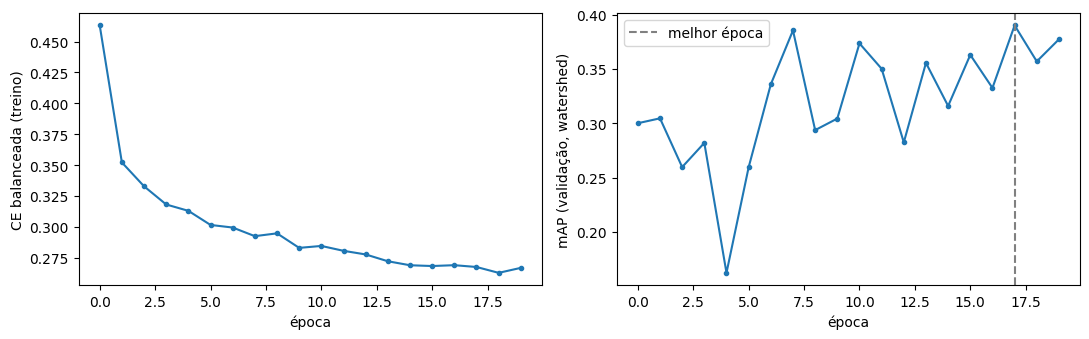

In [86]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
ax[0].plot(historico_3c["perda"], "-o", ms=3)
ax[0].set_xlabel("época")
ax[0].set_ylabel("CE balanceada (treino)")
ax[1].plot(historico_3c["val_mAP"], "-o", ms=3)
ax[1].axvline(int(np.argmax(historico_3c["val_mAP"])), ls="--", color="gray", label="melhor época")
ax[1].set_xlabel("época")
ax[1].set_ylabel("mAP (validação, watershed)")
ax[1].legend()
plt.tight_layout()
plt.show()

### 2.4 Métricas lado a lado com a baseline

Mesmo conjunto de teste, mesmo `avaliar_instancias`, mesma regra de matching; só muda o `segmentar`.

In [87]:
res_watershed = avaliar_instancias(segmentar_watershed, teste_real)
resultados = {"ingênuo": res_ingenuo, "watershed": res_watershed}

print(f"{'método':10s} | mAP   | erro de contagem")
for nome, res in resultados.items():
    print(f"{nome:10s} | {res['mAP']:.3f} | {res['erro_contagem_medio']:.2f}")

print(f"\n{'IoU >=':6s} | " + " | ".join(f"{nome:9s}" for nome in resultados))
for i, limiar in enumerate(LIMIARES_IOU):
    print(f"{limiar:6.2f} | " + " | ".join(f"{res['aps'][:, i].mean():9.3f}" for res in resultados.values()))

print(f"\n{'modalidade':15s} | " + " | ".join(f"mAP {nome:9s}" for nome in resultados))
for mod in modalidades:
    sel = res_watershed["modalidades"] == mod
    print(f"{mod:15s} | " + " | ".join(f"{res['maps'][sel].mean():13.3f}" for res in resultados.values()))

método     | mAP   | erro de contagem
ingênuo    | 0.488 | 2.20
watershed  | 0.370 | 2.28

IoU >= | ingênuo   | watershed
  0.50 |     0.685 |     0.627
  0.55 |     0.648 |     0.594
  0.60 |     0.620 |     0.556
  0.65 |     0.588 |     0.526
  0.70 |     0.550 |     0.471
  0.75 |     0.500 |     0.398
  0.80 |     0.468 |     0.279
  0.85 |     0.392 |     0.176
  0.90 |     0.283 |     0.069
  0.95 |     0.146 |     0.007

modalidade      | mAP ingênuo   | mAP watershed
campo_claro     |         0.098 |         0.064
fluorescencia   |         0.540 |         0.406
histologia      |         0.268 |         0.225


ingênuo    | Spearman(densidade, mAP) = -0.267 | Spearman(densidade, erro) = +0.516
watershed  | Spearman(densidade, mAP) = -0.160 | Spearman(densidade, erro) = +0.420


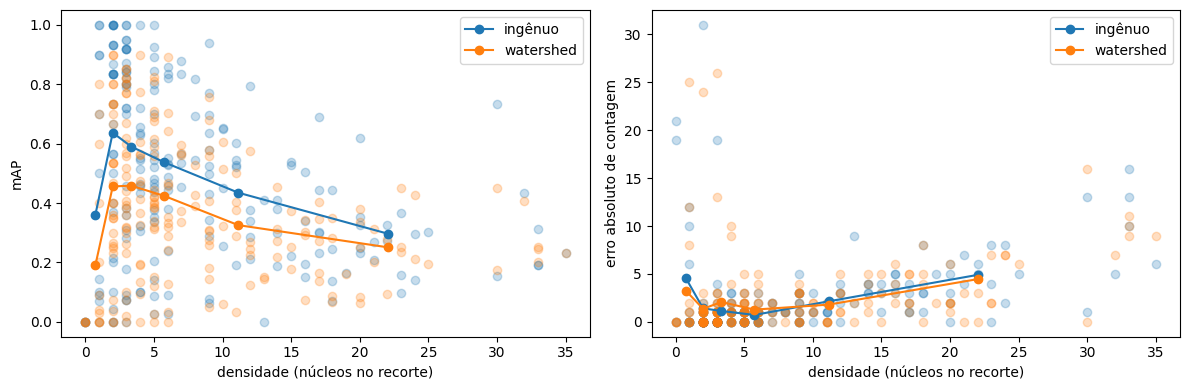

In [88]:
plotar_por_densidade(resultados)

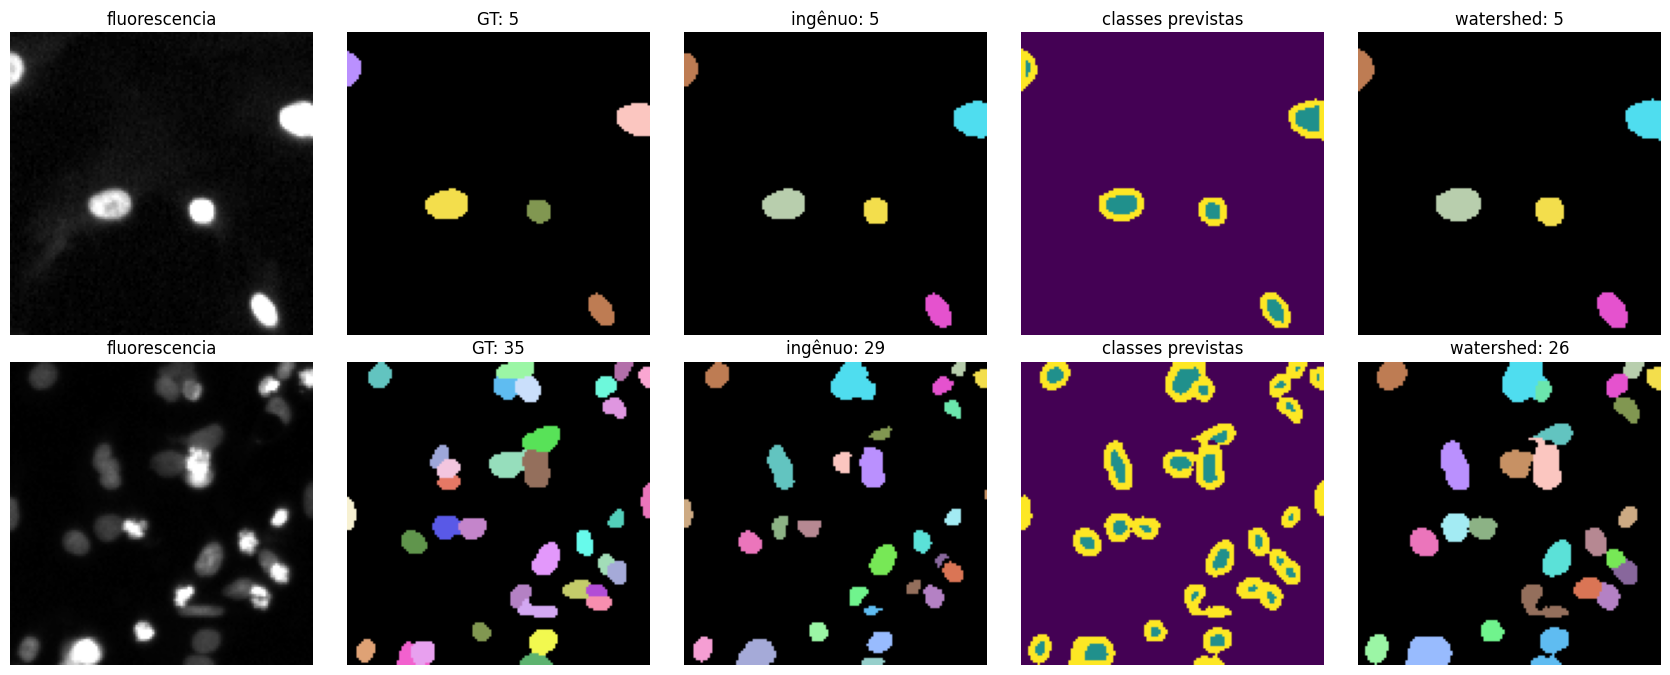

In [89]:
ordem = np.argsort(res_watershed["densidades"])
exemplos = [int(ordem[len(ordem) // 2]), int(ordem[-1])]

fig, axes = plt.subplots(len(exemplos), 5, figsize=(17, 3.4 * len(exemplos)))
for ax, k in zip(axes, exemplos):
    imagem, gt_labels = teste_real.amostra(k)
    ingenuo = segmentar_ingenuo(imagem)
    classes = prever_classes(modelo_3c, imagem)
    ws = decodificar_watershed(classes)

    ax[0].imshow(imagem, cmap="gray", vmin=0, vmax=1)
    ax[0].set_title(teste_real.modalidades[k])
    ax[1].imshow(colorir_instancias(gt_labels))
    ax[1].set_title(f"GT: {n_objetos(gt_labels)}")
    ax[2].imshow(colorir_instancias(ingenuo))
    ax[2].set_title(f"ingênuo: {n_objetos(ingenuo)}")
    ax[3].imshow(classes, cmap="viridis", vmin=0, vmax=2)
    ax[3].set_title("classes previstas")
    ax[4].imshow(colorir_instancias(ws))
    ax[4].set_title(f"watershed: {n_objetos(ws)}")

for ax in axes.ravel():
    ax.axis("off")
plt.tight_layout()
plt.show()

**Por que resolve o problema da Parte 1.** O ingênuo falha porque a representação binária não tem como codificar "aqui termina um núcleo e começa outro". A classe fronteira codifica exatamente isso, e o watershed a partir dos interiores transforma essa informação em instâncias separadas. O ganho deve aparecer onde a baseline mais perde: nos limiares altos de IoU e nos recortes densos. O teto de 2.2 separa o que ainda é perdido pela própria representação (fronteira reatribuída pelo watershed) do que é erro da rede.

## Parte 3 — Ablações

Dois eixos, cada configuração treinada com **2 seeds**, reportando **média ± desvio do mAP no teste** (watershed). Tudo o que não é o fator ablacionado fica fixo: os recortes e o rótulo de 3 classes da Parte 2, os flips, Adam com lr = 1e-3, a época escolhida pelo mAP na validação. As ablações usam 12 épocas em vez de 20 para caber no tempo; a comparação é relativa, não com o modelo final.

`ablacao` treina e guarda os modelos; as métricas são calculadas depois, para que o mesmo conjunto de modelos possa ser lido por mais de uma métrica (no Eixo 2 isso importa).

In [90]:
teste_3c = DadosTresClasses(teste_real, ESPESSURA)

def ablacao(configs, seeds=(0, 1), epocas=12):
    """Treina cada configuração {nome: (criar_modelo, criterio)} uma vez por seed e devolve {nome: [modelos]}."""
    modelos = {}
    for nome, (criar_modelo, criterio) in configs.items():
        modelos[nome] = []
        for seed in seeds:
            torch.manual_seed(seed)
            modelo = criar_modelo().to(device)
            historico = treinar(modelo, treino_3c, val_real, epocas, criterio, metrica_watershed,
                                augmentar=flip_aleatorio, seed=seed, verboso=False)
            modelos[nome].append(modelo)
            print(f"{nome:22s} | seed {seed} | melhor val mAP {max(historico['val_mAP']):.3f}")
    return modelos

def map_teste(modelo):
    segmentar = lambda imagem: decodificar_watershed(prever_classes(modelo, imagem))
    return avaliar_instancias(segmentar, teste_real)["mAP"]

def recall_fronteira(modelo):
    """Fração dos pixels de fronteira do gabarito que a rede classifica como fronteira."""
    acertos, total = 0, 0
    for imagem, classes in zip(teste_3c.imagens, teste_3c.classes):
        fronteira = classes == 2
        acertos += (prever_classes(modelo, imagem)[fronteira] == 2).sum()
        total += fronteira.sum()
    return acertos / total

def resumo(modelos, metrica):
    """{nome: array com a métrica de cada seed}"""
    return {nome: np.array([metrica(modelo) for modelo in lista]) for nome, lista in modelos.items()}

def plotar_ablacao(valores, ylabel, titulo):
    nomes = list(valores)
    medias = [valores[nome].mean() for nome in nomes]
    desvios = [valores[nome].std() for nome in nomes]

    plt.figure(figsize=(1.7 * len(nomes) + 2, 4))
    plt.bar(nomes, medias, yerr=desvios, capsize=6)
    for i, (media, desvio) in enumerate(zip(medias, desvios)):
        plt.text(i, media + desvio + 0.01, f"{media:.3f} ± {desvio:.3f}", ha="center", fontsize=9)
    plt.ylabel(ylabel)
    plt.ylim(0, max(medias) + 0.15)
    plt.title(titulo)
    plt.tight_layout()
    plt.show()

### 3.1 Eixo 1 — como recuperar resolução

Mesmo encoder (`enc1`, `enc2`, `meio`, com as mesmas larguras), dois decoders:

- **skip connections** (U-Net): o decoder recebe, por concatenação, o mapa de features completo de cada nível do encoder;
- **pool indices** (SegNet): o decoder recebe só a *posição* dos máximos de cada pooling (`MaxUnpool2d`) e reconstrói o resto por convolução.

A fronteira tem 2 px de espessura, então a aposta é que a informação de alta resolução que a skip connection carrega faz diferença justamente nessa classe.

In [91]:
class SegNetPequena(nn.Module):
    """Mesmo encoder da UNetPequena. No decoder, cada `up` é uma projeção 1×1 + max-unpooling com os índices
       do pooling (no lugar da convolução transposta) e não há skip connections."""
    def __init__(self, n_saidas=1):
        super().__init__()
        self.enc1 = bloco_conv(1, 16)
        self.enc2 = bloco_conv(16, 32)
        self.meio = bloco_conv(32, 64)
        self.pool = nn.MaxPool2d(2, return_indices=True)
        self.unpool = nn.MaxUnpool2d(2)
        self.up2 = nn.Conv2d(64, 32, 1)
        self.dec2 = bloco_conv(32, 32)
        self.up1 = nn.Conv2d(32, 16, 1)
        self.dec1 = bloco_conv(16, 16)
        self.saida = nn.Conv2d(16, n_saidas, 1)

    def forward(self, x):
        e1 = self.enc1(x)
        p1, idx1 = self.pool(e1)
        e2 = self.enc2(p1)
        p2, idx2 = self.pool(e2)
        m = self.meio(p2)
        d2 = self.dec2(self.unpool(self.up2(m), idx2, output_size=e2.size()))
        d1 = self.dec1(self.unpool(self.up1(d2), idx1, output_size=e1.size()))
        return self.saida(d1)

ce_balanceada = nn.CrossEntropyLoss(weight=pesos_classe)

configs_eixo1 = {
    "U-Net (skip)": (lambda: UNetPequena(n_saidas=3), ce_balanceada),
    "SegNet (unpool)": (lambda: SegNetPequena(n_saidas=3), ce_balanceada),
}

inicio = time.time()
modelos_eixo1 = ablacao(configs_eixo1)
print(f"\nEixo 1 em {(time.time() - inicio) / 60:.1f} min")

U-Net (skip)           | seed 0 | melhor val mAP 0.370
U-Net (skip)           | seed 1 | melhor val mAP 0.342
SegNet (unpool)        | seed 0 | melhor val mAP 0.339
SegNet (unpool)        | seed 1 | melhor val mAP 0.381

Eixo 1 em 6.6 min


decoder          | mAP teste
U-Net (skip)     | 0.341 ± 0.010
SegNet (unpool)  | 0.348 ± 0.022


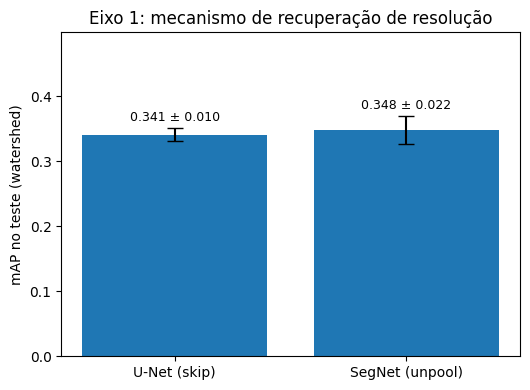

In [92]:
map_eixo1 = resumo(modelos_eixo1, map_teste)

print(f"{'decoder':16s} | mAP teste")
for nome, valores in map_eixo1.items():
    print(f"{nome:16s} | {valores.mean():.3f} ± {valores.std():.3f}")

plotar_ablacao(map_eixo1, "mAP no teste (watershed)", "Eixo 1: mecanismo de recuperação de resolução")

### 3.2 Eixo 2 — função de perda

CE → CE balanceada (α) → focal (γ) → focal balanceada, com γ ∈ {0, 1, 2, 5} (slides 73–79). Uma única classe implementa todas: com γ = 0 e sem α é a CE; α são os pesos por classe da Parte 2 (frequência mediana); γ > 0 reduz o peso dos pixels fáceis, que aqui são quase todos fundo e interior.

O desbalanceamento é severo — a fronteira é uma fração pequena dos pixels — então além do mAP medimos o **recall da classe fronteira**: é onde a perda deveria agir, e é o que o watershed precisa para separar vizinhos.

In [93]:
class FocalLoss(nn.Module):
    """γ = 0 sem α: CE. α: pesos por classe (CE balanceada, normalizada como a CrossEntropyLoss do torch). γ > 0: focal."""
    def __init__(self, gamma=0.0, alpha=None):
        super().__init__()
        self.gamma = gamma
        self.alpha = alpha

    def forward(self, logits, alvo):
        log_prob = torch.log_softmax(logits, dim=1).gather(1, alvo.unsqueeze(1)).squeeze(1)
        perda = -(1 - log_prob.exp()) ** self.gamma * log_prob
        if self.alpha is None:
            return perda.mean()
        pesos = self.alpha[alvo]
        return (pesos * perda).sum() / pesos.sum()

unet_3c = lambda: UNetPequena(n_saidas=3)

configs_eixo2 = {
    "CE": (unet_3c, FocalLoss(gamma=0)),
    "CE balanceada": (unet_3c, FocalLoss(gamma=0, alpha=pesos_classe)),
    "focal γ=1": (unet_3c, FocalLoss(gamma=1)),
    "focal γ=2": (unet_3c, FocalLoss(gamma=2)),
    "focal γ=5": (unet_3c, FocalLoss(gamma=5)),
    "focal bal. γ=2": (unet_3c, FocalLoss(gamma=2, alpha=pesos_classe)),
}

inicio = time.time()
modelos_eixo2 = ablacao(configs_eixo2)
print(f"\nEixo 2 em {(time.time() - inicio) / 60:.1f} min")

CE                     | seed 0 | melhor val mAP 0.507
CE                     | seed 1 | melhor val mAP 0.501
CE balanceada          | seed 0 | melhor val mAP 0.354
CE balanceada          | seed 1 | melhor val mAP 0.353
focal γ=1              | seed 0 | melhor val mAP 0.509
focal γ=1              | seed 1 | melhor val mAP 0.501
focal γ=2              | seed 0 | melhor val mAP 0.499
focal γ=2              | seed 1 | melhor val mAP 0.498
focal γ=5              | seed 0 | melhor val mAP 0.495
focal γ=5              | seed 1 | melhor val mAP 0.496
focal bal. γ=2         | seed 0 | melhor val mAP 0.387
focal bal. γ=2         | seed 1 | melhor val mAP 0.348

Eixo 2 em 22.6 min


perda            | mAP teste      | recall fronteira
CE               | 0.473 ± 0.001 | 0.494 ± 0.023
CE balanceada    | 0.345 ± 0.002 | 0.860 ± 0.021
focal γ=1        | 0.475 ± 0.007 | 0.514 ± 0.010
focal γ=2        | 0.466 ± 0.006 | 0.517 ± 0.017
focal γ=5        | 0.467 ± 0.006 | 0.527 ± 0.010
focal bal. γ=2   | 0.361 ± 0.027 | 0.852 ± 0.019


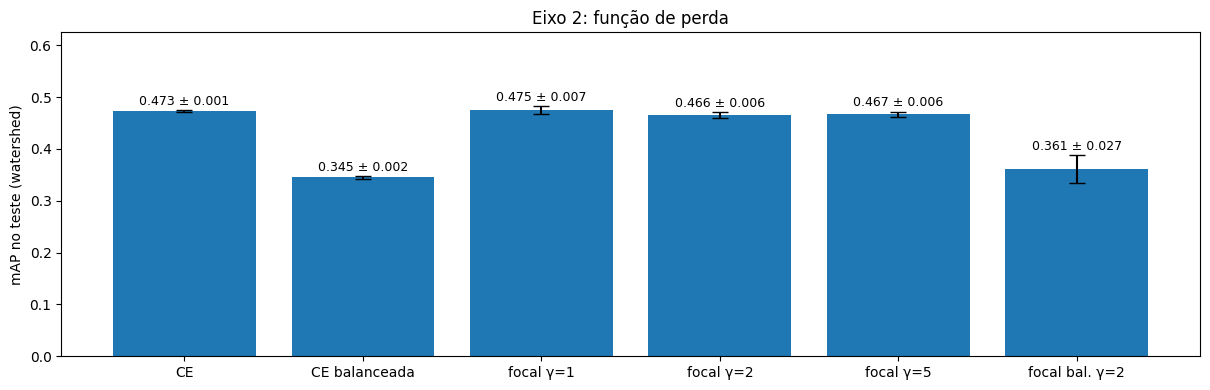

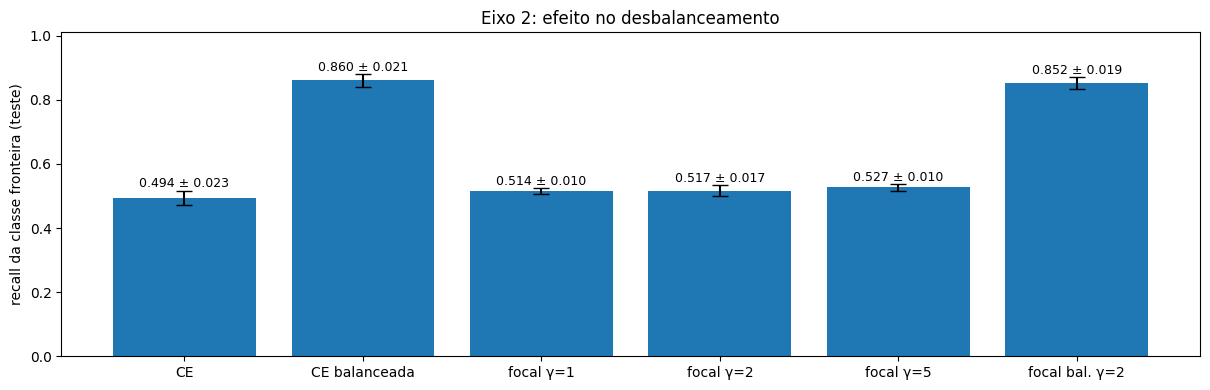

In [94]:
map_eixo2 = resumo(modelos_eixo2, map_teste)
recall_eixo2 = resumo(modelos_eixo2, recall_fronteira)

print(f"{'perda':16s} | mAP teste      | recall fronteira")
for nome in configs_eixo2:
    print(f"{nome:16s} | {map_eixo2[nome].mean():.3f} ± {map_eixo2[nome].std():.3f} | {recall_eixo2[nome].mean():.3f} ± {recall_eixo2[nome].std():.3f}")

plotar_ablacao(map_eixo2, "mAP no teste (watershed)", "Eixo 2: função de perda")
plotar_ablacao(recall_eixo2, "recall da classe fronteira (teste)", "Eixo 2: efeito no desbalanceamento")

**Leitura.** No Eixo 1 a diferença entre os decoders deve concentrar-se nos limiares altos de IoU e na fronteira, que é fina: a skip connection entrega detalhe de resolução plena que o unpooling só reconstrói parcialmente. No Eixo 2 a pergunta é se o mAP acompanha o recall da fronteira: balancear ou focalizar aumenta o recall, mas a partir de certo ponto a rede passa a prever fronteira demais e os interiores encolhem ou se partem — marcadores a mais e mAP menor. É esse ponto de virada, e não o recall máximo, que define a perda do modelo final.

## Parte 4 — Inferência em mosaico

Imagens maiores que a entrada da rede são processadas em *tiles* sobrepostos, e as previsões são combinadas na sobreposição (slide 83). Para segmentação semântica basta tirar a média. Para instâncias há uma armadilha: se cada tile é decodificado sozinho, um núcleo que cai na emenda vira dois objetos, um em cada tile.

Tudo nesta parte usa o `modelo_3c` da Parte 2, sem retreinar.

### 4.1 Imagem grande

Mosaico 2×2 com os primeiros quatro recortes 256×256 de imagens de fluorescência do teste (512×512 no total, com muitas emendas de tile pela frente). Os ids das instâncias são deslocados por quadrante para continuarem únicos.

imagem: (512, 512) | núcleos: 86


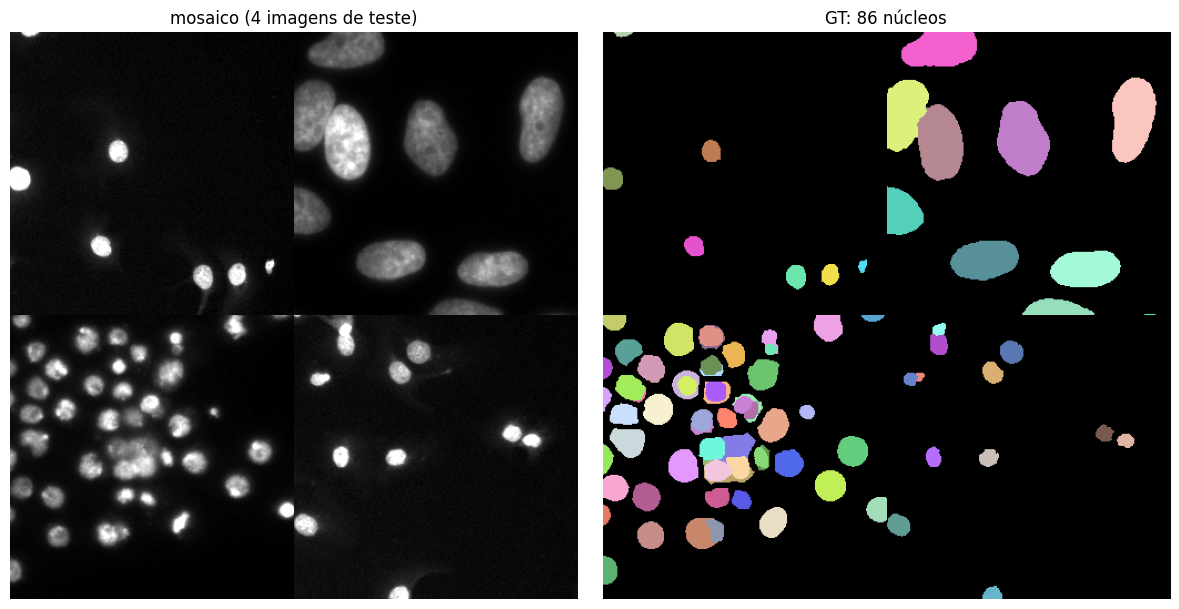

In [11]:
LADO_QUADRANTE = 256

quadrantes = [i for i in idx_teste
              if itens_bbbc[i]["modalidade"] == "fluorescencia" and min(itens_bbbc[i]["imagem"].shape) >= LADO_QUADRANTE][:4]

imagem_grande = np.zeros((2 * LADO_QUADRANTE, 2 * LADO_QUADRANTE), dtype=np.float32)
inst_grande = np.zeros_like(imagem_grande, dtype=np.int32)

for q, i in enumerate(quadrantes):
    y0, x0 = LADO_QUADRANTE * (q // 2), LADO_QUADRANTE * (q % 2)
    recorte = slice(y0, y0 + LADO_QUADRANTE), slice(x0, x0 + LADO_QUADRANTE)
    imagem_grande[recorte] = itens_bbbc[i]["imagem"][:LADO_QUADRANTE, :LADO_QUADRANTE] / 255
    inst = itens_bbbc[i]["inst"][:LADO_QUADRANTE, :LADO_QUADRANTE].astype(np.int32)
    inst_grande[recorte] = np.where(inst > 0, inst + inst_grande.max(), 0)

print("imagem:", imagem_grande.shape, "| núcleos:", n_objetos(inst_grande))

fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].imshow(imagem_grande, cmap="gray", vmin=0, vmax=1)
ax[0].set_title("mosaico (4 imagens de teste)")
ax[1].imshow(colorir_instancias(inst_grande))
ax[1].set_title(f"GT: {n_objetos(inst_grande)} núcleos")
for a in ax:
    a.axis("off")
plt.tight_layout()
plt.show()

### 4.2 Inferência em tiles com sobreposição

Tiles de 128×128 (o tamanho de treino) com passo 96, ou seja, 32 px de sobreposição; o último tile de cada linha/coluna é encostado na borda. A versão **por tile** decodifica cada tile com o watershed e cola as instâncias na imagem grande, dando id novo a cada pedaço que ainda não foi coberto — é o que acontece quando se trata o rótulo de instância como se fosse um rótulo semântico.

In [83]:
TILE, PASSO = 128, 96

def inicios(tamanho, tile=TILE, passo=PASSO):
    posicoes = list(range(0, tamanho - tile + 1, passo))
    if posicoes[-1] != tamanho - tile:
        posicoes.append(tamanho - tile)
    return posicoes

def tiles(imagem):
    for y in inicios(imagem.shape[0]):
        for x in inicios(imagem.shape[1]):
            yield slice(y, y + TILE), slice(x, x + TILE)

def prob_classes(modelo, imagem):
    modelo.eval()
    x = torch.from_numpy(imagem)[None, None].to(device)
    with torch.no_grad():
        return torch.softmax(modelo(x), dim=1)[0].cpu().numpy()

def inferir_por_tile(modelo, imagem):
    """Decodifica cada tile sozinho e cola na imagem grande; cada pedaço novo recebe um id novo."""
    resultado = np.zeros(imagem.shape, dtype=np.int32)
    for janela in tiles(imagem):
        inst_tile = decodificar_watershed(prob_classes(modelo, imagem[janela]).argmax(0))
        destino = resultado[janela]
        for k in ids_objetos(inst_tile):
            novo = (inst_tile == k) & (destino == 0)
            if novo.any():
                destino[novo] = resultado.max() + 1
    return resultado

pred_por_tile = inferir_por_tile(modelo_3c, imagem_grande)

def fracao_segundo_pedaco(pred, gt):
    """Para cada núcleo do gabarito, a fração da sua área coberta pelo segundo maior objeto previsto (0 = ficou inteiro)."""
    fracoes = []
    for k in ids_objetos(gt):
        dentro = pred[gt == k]
        areas = np.sort(np.bincount(dentro[dentro != 0]))[::-1]
        fracoes.append(areas[1] / dentro.size if len(areas) > 1 else 0.0)
    return np.array(fracoes)

def n_partidos(pred, gt):
    return (fracao_segundo_pedaco(pred, gt) >= 0.1).sum()

print(f"por tile: {n_objetos(pred_por_tile)} objetos para {n_objetos(inst_grande)} núcleos"
      f" | mAP {aps_de_uma_imagem(pred_por_tile, inst_grande).mean():.3f}"
      f" | núcleos partidos: {n_partidos(pred_por_tile, inst_grande)}")

por tile: 129 objetos para 86 núcleos | mAP 0.215 | núcleos partidos: 19


### 4.3 Um objeto na fronteira entre dois tiles

Um núcleo conta como **partido** quando o segundo maior objeto previsto dentro dele cobre pelo menos 10% da sua área (pedaços menores são só a borda do tile mordendo o contorno). A figura mostra o núcleo mais partido pela inferência por tile, com as bordas dos tiles desenhadas por cima.

In [84]:
def mostrar_emenda(pred_antes, pred_depois, lado=96):
    fracoes = fracao_segundo_pedaco(pred_antes, inst_grande)
    k = ids_objetos(inst_grande)[np.argmax(fracoes)]
    cy, cx = ndimage.center_of_mass(inst_grande == k)
    y0 = int(np.clip(cy - lado / 2, 0, inst_grande.shape[0] - lado))
    x0 = int(np.clip(cx - lado / 2, 0, inst_grande.shape[1] - lado))
    janela = slice(y0, y0 + lado), slice(x0, x0 + lado)

    paineis = [(imagem_grande[janela], "imagem", "gray"),
               (colorir_instancias(inst_grande[janela]), "GT", None),
               (colorir_instancias(pred_antes[janela]), f"por tile (2º pedaço = {fracoes.max():.0%} da área)", None),
               (colorir_instancias(pred_depois[janela]), "corrigido", None)]

    fig, ax = plt.subplots(1, 4, figsize=(16, 4))
    for a, (painel, titulo, cmap) in zip(ax, paineis):
        a.imshow(painel, cmap=cmap, vmin=0, vmax=1)
        a.set_title(titulo)
        for borda in {*inicios(inst_grande.shape[0]), *(p + TILE for p in inicios(inst_grande.shape[0]))}:
            if y0 < borda < y0 + lado:
                a.axhline(borda - y0, color="white", ls="--", lw=1)
        for borda in {*inicios(inst_grande.shape[1]), *(p + TILE for p in inicios(inst_grande.shape[1]))}:
            if x0 < borda < x0 + lado:
                a.axvline(borda - x0, color="white", ls="--", lw=1)
        a.axis("off")
    plt.tight_layout()
    plt.show()

### 4.4 Correção: fundir antes de decodificar

A representação de 3 classes permite a correção mais simples possível: a identidade da instância só nasce no watershed, então basta fundir **o mapa de classes** — média das probabilidades na sobreposição, exatamente como no slide 83 — e decodificar a imagem grande uma única vez. Não há instâncias para casar entre tiles porque nenhum tile chegou a produzir instâncias. Uma representação que decodifica dentro do tile (embeddings + clustering, por exemplo) precisaria da fusão por IoU na faixa de sobreposição.

método     | objetos | mAP   | núcleos partidos
por tile   |     129 | 0.215 | 19
fundido    |     110 | 0.204 | 29
GT         |      86


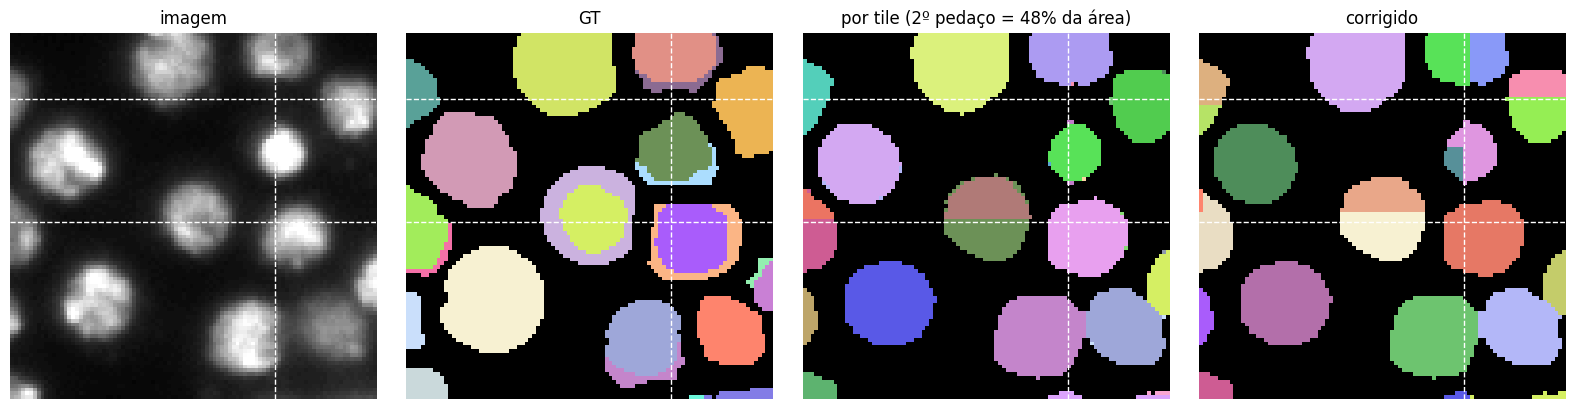

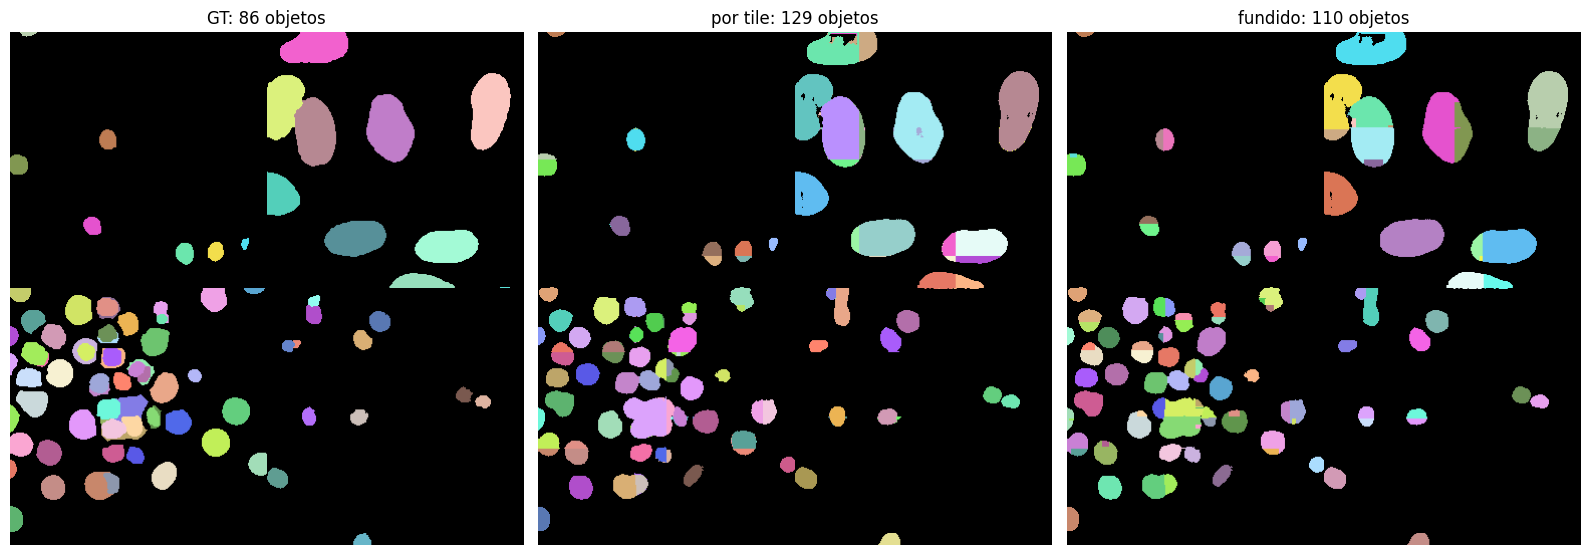

In [85]:
def inferir_fundido(modelo, imagem):
    """Média das probabilidades das 3 classes na sobreposição dos tiles; um único watershed no fim."""
    soma = np.zeros((3, *imagem.shape), dtype=np.float32)
    cobertura = np.zeros(imagem.shape, dtype=np.float32)
    for janela in tiles(imagem):
        soma[(slice(None), *janela)] += prob_classes(modelo, imagem[janela])
        cobertura[janela] += 1
    return decodificar_watershed((soma / cobertura).argmax(0))

pred_fundido = inferir_fundido(modelo_3c, imagem_grande)

print(f"{'método':10s} | objetos | mAP   | núcleos partidos")
for nome, pred in [("por tile", pred_por_tile), ("fundido", pred_fundido)]:
    print(f"{nome:10s} | {n_objetos(pred):7d} | {aps_de_uma_imagem(pred, inst_grande).mean():.3f} | {n_partidos(pred, inst_grande)}")
print(f"{'GT':10s} | {n_objetos(inst_grande):7d}")

mostrar_emenda(pred_por_tile, pred_fundido)

fig, ax = plt.subplots(1, 3, figsize=(16, 5.5))
for a, (pred, titulo) in zip(ax, [(inst_grande, "GT"), (pred_por_tile, "por tile"), (pred_fundido, "fundido")]):
    a.imshow(colorir_instancias(pred))
    a.set_title(f"{titulo}: {n_objetos(pred)} objetos")
    a.axis("off")
plt.tight_layout()
plt.show()

## Parte 5 — Galeria de falhas

Cinco recortes do teste em que o `modelo_3c` erra feio, cada um com a figura (imagem, gabarito, mapa de classes previsto, instâncias) e um diagnóstico apoiado em medidas do próprio recorte. Antes disso, o obrigatório: o campo receptivo teórico do encoder contra a distribuição de tamanhos dos núcleos. No fim, uma correção sugerida por um dos diagnósticos, com antes/depois.

### 5.1 Campo receptivo teórico

Recorrência dos slides 35–38: uma camada de kernel $k$ amplia o campo em $(k-1)\cdot$pulo, e o pulo é multiplicado pelo stride. A `UNetPequena` tem dois níveis de pooling; o enunciado pede o campo do **encoder**, mas o pixel de saída também enxerga pelo decoder (convoluções depois do upsampling, com pulo menor), então calculamos os dois.

In [86]:
def campo_receptivo(camadas):
    """camadas: (nome, kernel, stride); stride < 1 é upsampling. Devolve o campo receptivo em pixels da entrada."""
    rf, pulo = 1, 1
    for nome, kernel, stride in camadas:
        if stride < 1:
            pulo *= stride
        rf += (kernel - 1) * pulo
        if stride >= 1:
            pulo *= stride
    return int(rf)

bloco = [("conv 3x3", 3, 1), ("conv 3x3", 3, 1)]
encoder = bloco + [("maxpool 2", 2, 2)] + bloco + [("maxpool 2", 2, 2)] + bloco
decoder = [("convT 2x2", 2, 0.5)] + bloco + [("convT 2x2", 2, 0.5)] + bloco

RF_ENCODER = campo_receptivo(encoder)
RF_TOTAL = campo_receptivo(encoder + decoder)
print(f"campo receptivo do encoder (até o meio da U): {RF_ENCODER} px")
print(f"campo receptivo até a saída (encoder + decoder): {RF_TOTAL} px")

campo receptivo do encoder (até o meio da U): 32 px
campo receptivo até a saída (encoder + decoder): 47 px


### 5.2 Tamanho dos núcleos no dataset

Eixo maior de cada núcleo (`regionprops`) nas 670 imagens inteiras, por modalidade — não nos recortes, onde núcleos cortados pela borda teriam o tamanho subestimado. Um núcleo maior que o campo receptivo é um núcleo cujo pixel central nunca enxerga as duas bordas ao mesmo tempo: a rede decide "interior" ou "fronteira" sem ver o objeto inteiro.

modalidade      | núcleos | mediana | p95   | máx   | > 32 px (encoder) | > 47 px (total)
campo_claro     |    1364 |    18.6 |  31.7 | 141.6 |               4.1% |             0.9%
fluorescencia   |   23541 |    24.9 |  62.4 | 154.2 |              33.2% |            10.8%
histologia      |    4556 |    24.8 |  59.7 | 140.3 |              26.3% |            10.0%
todas           |   29461 |    24.6 |  61.4 | 154.2 |              30.8% |            10.2%


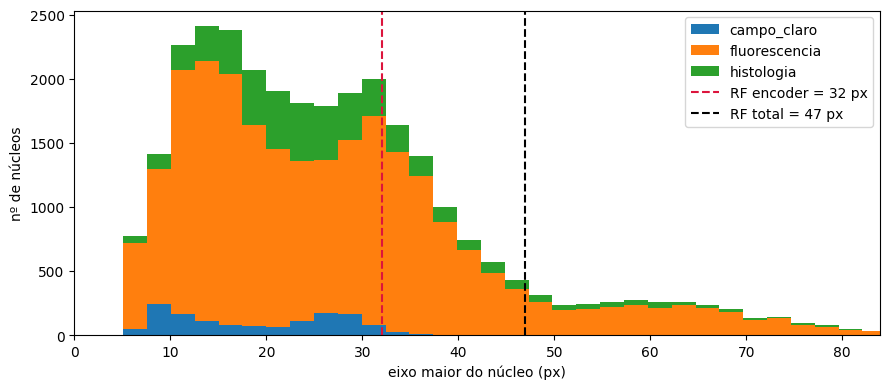

In [87]:
eixo_maior = {mod: [] for mod in modalidades}
for item in itens_bbbc:
    eixo_maior[item["modalidade"]] += [r.axis_major_length for r in regionprops(item["inst"].astype(np.int32))]
eixo_maior = {mod: np.array(v) for mod, v in eixo_maior.items()}
todos = np.concatenate(list(eixo_maior.values()))

print(f"{'modalidade':15s} | núcleos | mediana | p95   | máx   | > {RF_ENCODER} px (encoder) | > {RF_TOTAL} px (total)")
for mod, v in eixo_maior.items():
    print(f"{mod:15s} | {len(v):7d} | {np.median(v):7.1f} | {np.percentile(v, 95):5.1f} | {v.max():5.1f} | {(v > RF_ENCODER).mean():18.1%} | {(v > RF_TOTAL).mean():16.1%}")
print(f"{'todas':15s} | {len(todos):7d} | {np.median(todos):7.1f} | {np.percentile(todos, 95):5.1f} | {todos.max():5.1f} | {(todos > RF_ENCODER).mean():18.1%} | {(todos > RF_TOTAL).mean():16.1%}")

plt.figure(figsize=(9, 4))
plt.hist([eixo_maior[mod] for mod in modalidades], bins=60, stacked=True, label=list(modalidades))
plt.axvline(RF_ENCODER, color="crimson", ls="--", label=f"RF encoder = {RF_ENCODER} px")
plt.axvline(RF_TOTAL, color="black", ls="--", label=f"RF total = {RF_TOTAL} px")
plt.xlabel("eixo maior do núcleo (px)")
plt.ylabel("nº de núcleos")
plt.xlim(0, np.percentile(todos, 99.5))
plt.legend()
plt.tight_layout()
plt.show()

### 5.3 Galeria

Os cinco recortes de menor mAP entre os que têm pelo menos 3 núcleos (com 1 ou 2 núcleos, um erro só zera o mAP sem dizer muito). Para cada um, além da figura, quatro medidas que separam os mecanismos de falha:

- **maior eixo**: o maior núcleo do recorte contra o campo receptivo;
- **recall da fronteira**: fração dos pixels de fronteira do gabarito previstos como fronteira — baixa quando a rede não vê o contato entre núcleos;
- **fundidos**: núcleos do gabarito que caíram no mesmo objeto previsto (marcador faltando);
- **partidos**: núcleos com um segundo pedaço previsto de pelo menos 10% da área (marcador sobrando — fronteira falsa dentro do núcleo);
- **perdidos**: núcleos sem nenhum pixel previsto.

O diagnóstico impresso é escolhido por regras a partir dessas medidas, na ordem: objeto maior que o campo receptivo → fronteira não detectada entre vizinhos → interior sem marcador (núcleo pequeno demais para o anel de 2 px) → falha de foreground (contraste / modalidade rara).

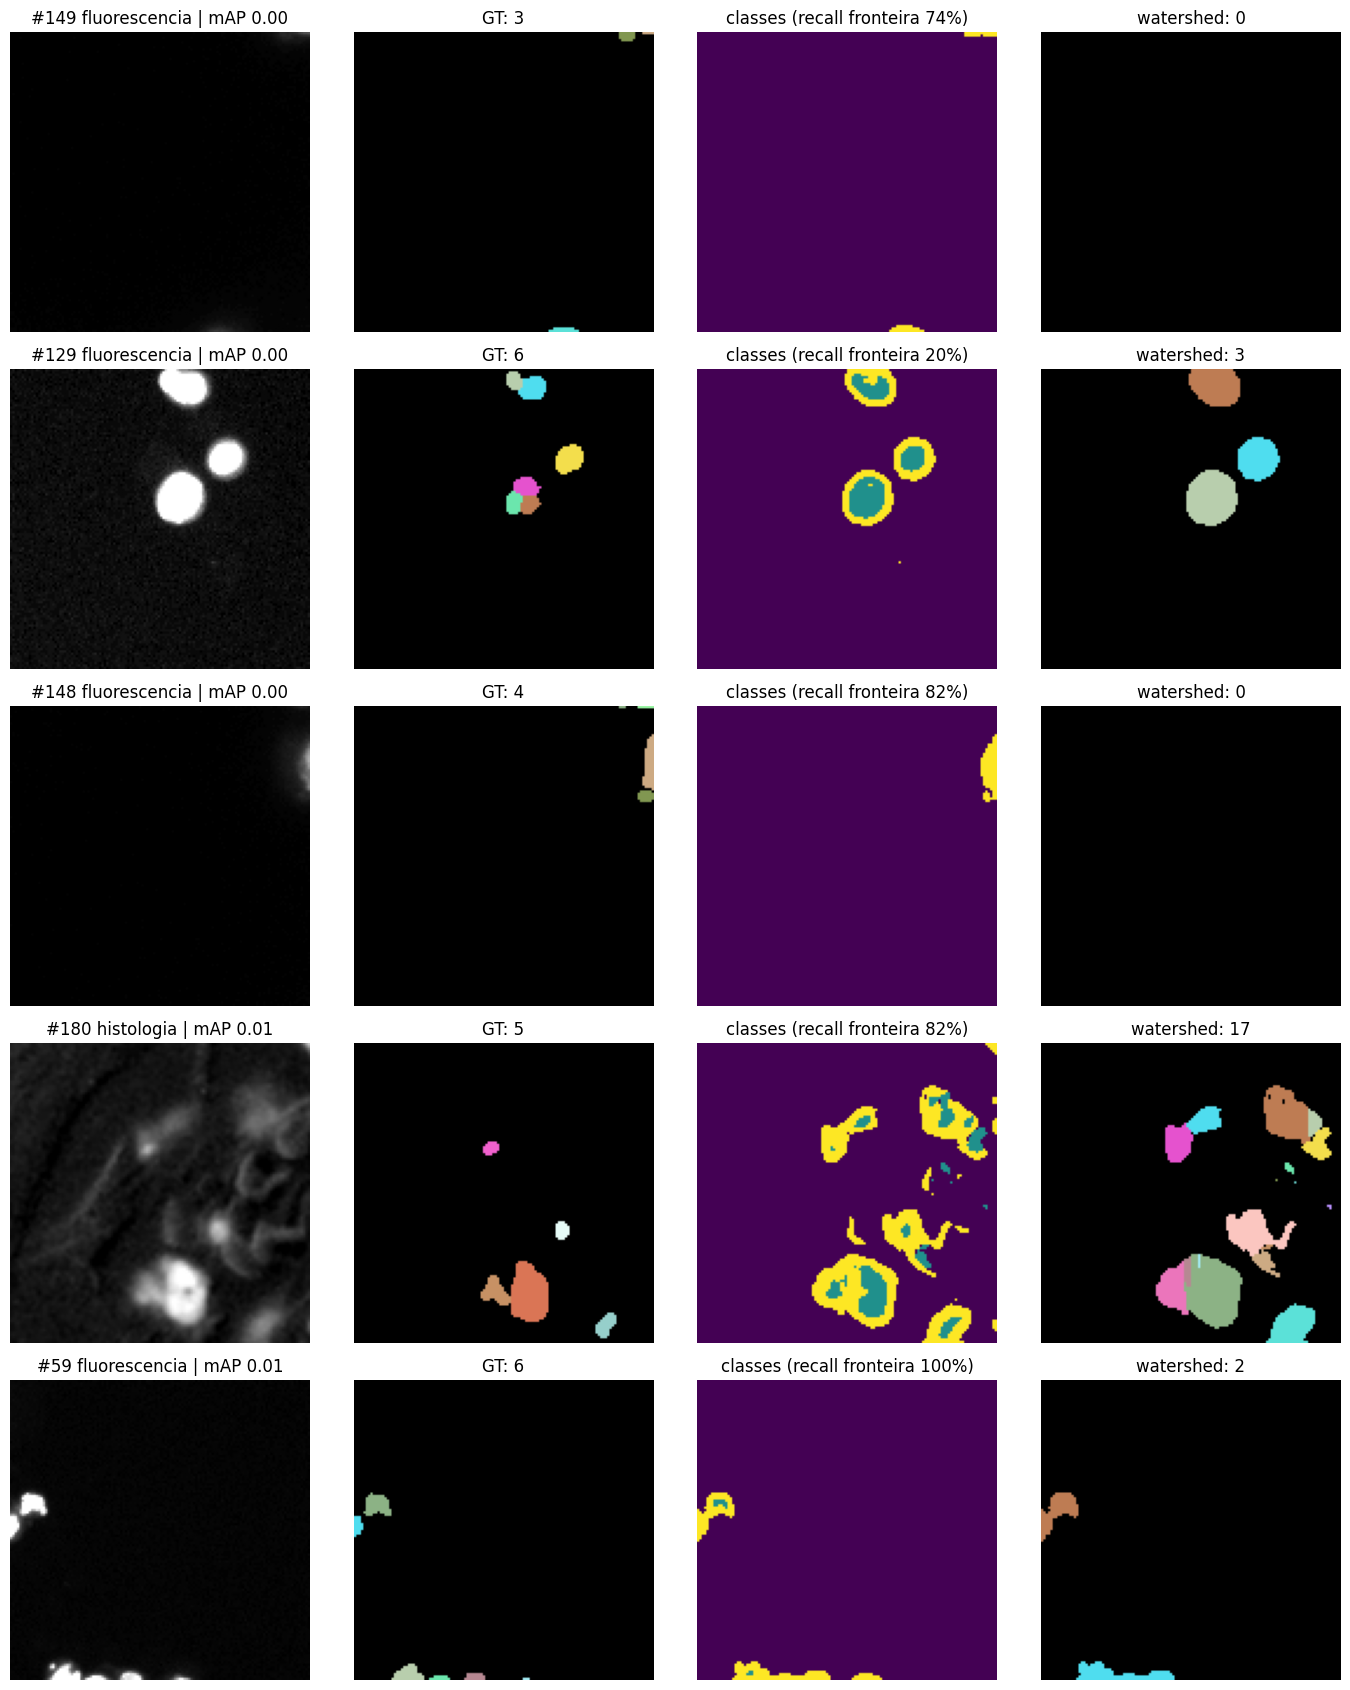

   # | modalidade    | GT | prev | maior eixo | recall front. | fund. | part. | perd.
 149 | fluorescencia |  3 |    0 |      13 px |           74% |     0 |     0 |     3
 129 | fluorescencia |  6 |    3 |      14 px |           20% |     5 |     0 |     0
 148 | fluorescencia |  4 |    0 |      25 px |           82% |     0 |     0 |     4
 180 | histologia    |  5 |   17 |      26 px |           82% |     0 |     1 |     0
  59 | fluorescencia |  6 |    2 |      13 px |          100% |     5 |     0 |     1

#149: falha de foreground (fluorescencia): 3 perdidos, 0 previstos para 3
#129: fronteira entre vizinhos não detectada (recall 20%): 5 núcleos fundidos num marcador só
#148: falha de foreground (fluorescencia): 4 perdidos, 0 previstos para 4
#180: falha de foreground (histologia): 0 perdidos, 17 previstos para 5
#59: falha de foreground (fluorescencia): 1 perdidos, 2 previstos para 6


In [88]:
def medidas(k, modelo=modelo_3c):
    imagem, gt = teste_real.amostra(k)
    classes = prever_classes(modelo, imagem)
    pred = decodificar_watershed(classes)
    gt_classes = rotulo_3classes(gt, ESPESSURA)

    dono = {}
    for j in ids_objetos(gt):
        dentro = pred[gt == j]
        dentro = dentro[dentro != 0]
        dono[j] = np.bincount(dentro).argmax() if dentro.size else 0
    ids_pred, vezes = np.unique([d for d in dono.values() if d > 0], return_counts=True)
    fundidos = vezes[vezes >= 2].sum()

    return {"modalidade": teste_real.modalidades[k],
            "n_gt": n_objetos(gt), "n_pred": n_objetos(pred),
            "mAP": res_watershed["maps"][k],
            "maior_eixo": max(r.axis_major_length for r in regionprops(gt)),
            "recall_fronteira": (classes[gt_classes == 2] == 2).mean(),
            "fundidos": int(fundidos),
            "partidos": int((fracao_segundo_pedaco(pred, gt) >= 0.1).sum()),
            "perdidos": int(sum(d == 0 for d in dono.values()))}

def diagnostico(m):
    if m["maior_eixo"] > RF_TOTAL:
        return (f"núcleo de {m['maior_eixo']:.0f} px > campo receptivo de {RF_TOTAL} px: o centro não enxerga as bordas, "
                f"vira fronteira falsa e o núcleo se parte ({m['partidos']} partidos)")
    if m["fundidos"] >= 2 and m["recall_fronteira"] < 0.5:
        return (f"fronteira entre vizinhos não detectada (recall {m['recall_fronteira']:.0%}): "
                f"{m['fundidos']} núcleos fundidos num marcador só")
    if m["perdidos"] > 0 and m["maior_eixo"] < 4 * ESPESSURA:
        return f"núcleos pequenos (< {4 * ESPESSURA} px) ficam sem interior com anel de {ESPESSURA} px: {m['perdidos']} perdidos"
    if m["perdidos"] > 0 or m["n_pred"] > 2 * m["n_gt"]:
        return f"falha de foreground ({m['modalidade']}): {m['perdidos']} perdidos, {m['n_pred']} previstos para {m['n_gt']}"
    return f"erro de contorno: {m['fundidos']} fundidos, {m['partidos']} partidos, recall da fronteira {m['recall_fronteira']:.0%}"

elegiveis = np.where(res_watershed["densidades"] >= 3)[0]
galeria = elegiveis[np.argsort(res_watershed["maps"][elegiveis])[:5]]
medidas_galeria = [medidas(k) for k in galeria]

fig, axes = plt.subplots(5, 4, figsize=(14, 17))
for ax, k, m in zip(axes, galeria, medidas_galeria):
    imagem, gt = teste_real.amostra(k)
    classes = prever_classes(modelo_3c, imagem)
    ax[0].imshow(imagem, cmap="gray", vmin=0, vmax=1)
    ax[0].set_title(f"#{k} {m['modalidade']} | mAP {m['mAP']:.2f}")
    ax[1].imshow(colorir_instancias(gt))
    ax[1].set_title(f"GT: {m['n_gt']}")
    ax[2].imshow(classes, cmap="viridis", vmin=0, vmax=2)
    ax[2].set_title(f"classes (recall fronteira {m['recall_fronteira']:.0%})")
    ax[3].imshow(colorir_instancias(decodificar_watershed(classes)))
    ax[3].set_title(f"watershed: {m['n_pred']}")
for ax in axes.ravel():
    ax.axis("off")
plt.tight_layout()
plt.show()

print(f"{'#':>4s} | {'modalidade':13s} | GT | prev | maior eixo | recall front. | fund. | part. | perd.")
for k, m in zip(galeria, medidas_galeria):
    print(f"{k:4d} | {m['modalidade']:13s} | {m['n_gt']:2d} | {m['n_pred']:4d} | {m['maior_eixo']:7.0f} px | {m['recall_fronteira']:13.0%} | {m['fundidos']:5d} | {m['partidos']:5d} | {m['perdidos']:5d}")
print()
for k, m in zip(galeria, medidas_galeria):
    print(f"#{k}: {diagnostico(m)}")

### 5.4 Correção: encoder mais profundo

O diagnóstico escolhido é o do campo receptivo: com dois níveis de pooling a saída enxerga 47 px, e a tabela de 5.2 diz que fração dos núcleos passa disso. A mudança que ele sugere é um terceiro nível de pooling — `UNetProfunda` tem o mesmo bloco e as mesmas larguras, mais um estágio de 128 canais; o campo receptivo passa a mais que o dobro. Nada mais muda: mesmos recortes, rótulo, perda, flips, seleção da época.

O teste do diagnóstico não é o mAP global, e sim a separação por tamanho: se o diagnóstico está certo, o ganho concentra-se nos recortes cujo maior núcleo excede o campo receptivo antigo e é pequeno nos demais. Ganho uniforme (ou nenhum) significa que o problema é outro — capacidade ou fronteira — e não o campo receptivo.

In [89]:
class UNetProfunda(nn.Module):
    """UNetPequena com um terceiro nível de pooling."""
    def __init__(self, n_saidas=1):
        super().__init__()
        self.enc1 = bloco_conv(1, 16)
        self.enc2 = bloco_conv(16, 32)
        self.enc3 = bloco_conv(32, 64)
        self.meio = bloco_conv(64, 128)
        self.pool = nn.MaxPool2d(2)
        self.up3 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.dec3 = bloco_conv(128, 64)
        self.up2 = nn.ConvTranspose2d(64, 32, 2, stride=2)
        self.dec2 = bloco_conv(64, 32)
        self.up1 = nn.ConvTranspose2d(32, 16, 2, stride=2)
        self.dec1 = bloco_conv(32, 16)
        self.saida = nn.Conv2d(16, n_saidas, 1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        m = self.meio(self.pool(e3))
        d3 = self.dec3(torch.cat([self.up3(m), e3], dim=1))
        d2 = self.dec2(torch.cat([self.up2(d3), e2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1))
        return self.saida(d1)

encoder_profundo = encoder + [("maxpool 2", 2, 2)] + bloco
decoder_profundo = [("convT 2x2", 2, 0.5)] + bloco + decoder
RF_PROFUNDO = campo_receptivo(encoder_profundo + decoder_profundo)
print(f"campo receptivo total: {RF_TOTAL} px -> {RF_PROFUNDO} px")

modelo_profundo = UNetProfunda(n_saidas=3).to(device)

inicio = time.time()
historico_profundo = treinar(modelo_profundo, treino_3c, val_real, epocas=20, criterio=nn.CrossEntropyLoss(weight=pesos_classe),
                             metricas=metrica_watershed, augmentar=flip_aleatorio)
print(f"treinou em {time.time() - inicio:.1f}s")
torch.save(modelo_profundo.state_dict(), "checkpoints/unet_profunda_3classes_bbbc038.pt")

campo receptivo total: 47 px -> 103 px
época  1 | perda 0.535 | val_mAP 0.290
época  2 | perda 0.378 | val_mAP 0.280
época  3 | perda 0.340 | val_mAP 0.246
época  4 | perda 0.319 | val_mAP 0.307
época  5 | perda 0.316 | val_mAP 0.184
época  6 | perda 0.299 | val_mAP 0.316
época  7 | perda 0.296 | val_mAP 0.322
época  8 | perda 0.291 | val_mAP 0.338
época  9 | perda 0.292 | val_mAP 0.280
época 10 | perda 0.282 | val_mAP 0.300
época 11 | perda 0.284 | val_mAP 0.373
época 12 | perda 0.281 | val_mAP 0.371
época 13 | perda 0.281 | val_mAP 0.277
época 14 | perda 0.271 | val_mAP 0.347
época 15 | perda 0.267 | val_mAP 0.337
época 16 | perda 0.269 | val_mAP 0.351
época 17 | perda 0.263 | val_mAP 0.343
época 18 | perda 0.262 | val_mAP 0.415
época 19 | perda 0.260 | val_mAP 0.339
época 20 | perda 0.255 | val_mAP 0.378
treinou em 75.6s


recortes                   | n   | mAP antes | mAP depois | ganho
todos                      | 200 |     0.372 |      0.390 | +0.018
maior núcleo > 47 px       |  59 |     0.477 |      0.492 | +0.014
maior núcleo <= 47 px      | 141 |     0.328 |      0.347 | +0.019


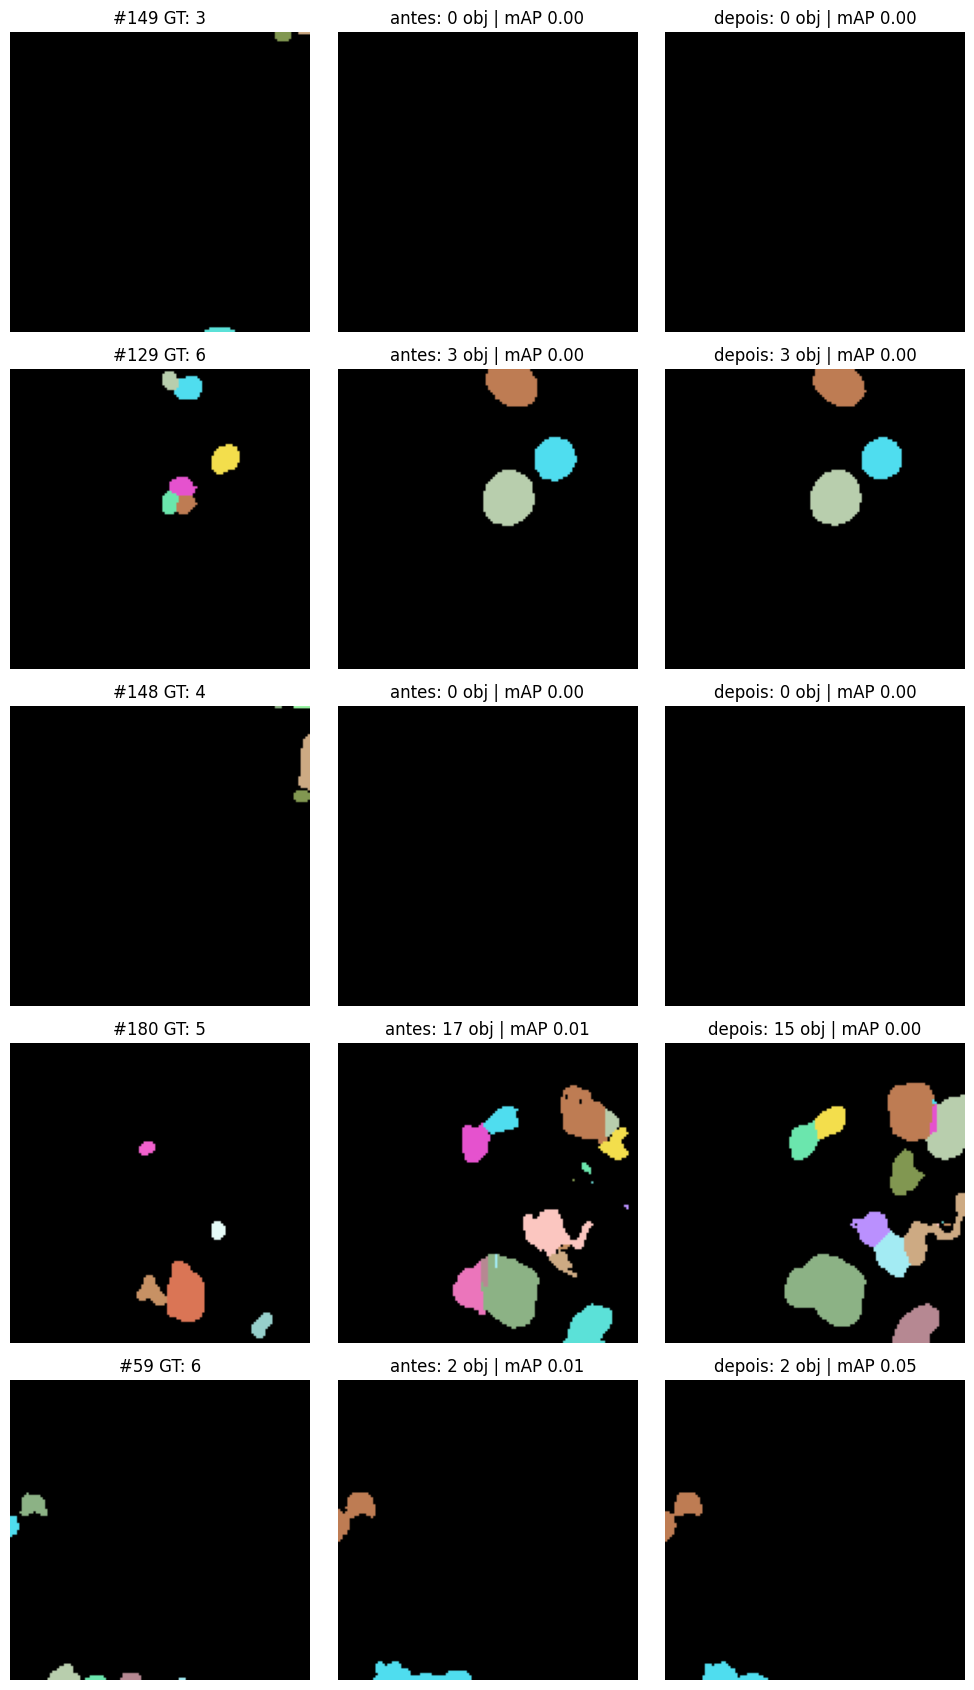

In [90]:
res_profundo = avaliar_instancias(lambda imagem: decodificar_watershed(prever_classes(modelo_profundo, imagem)), teste_real)

maior_eixo_teste = np.array([max((r.axis_major_length for r in regionprops(gt)), default=0) for gt in teste_real.instancias])
grupos = {"todos": np.ones(len(teste_real), dtype=bool),
          f"maior núcleo > {RF_TOTAL} px": maior_eixo_teste > RF_TOTAL,
          f"maior núcleo <= {RF_TOTAL} px": maior_eixo_teste <= RF_TOTAL}

print(f"{'recortes':26s} | n   | mAP antes | mAP depois | ganho")
for nome, sel in grupos.items():
    antes, depois = res_watershed["maps"][sel].mean(), res_profundo["maps"][sel].mean()
    print(f"{nome:26s} | {sel.sum():3d} | {antes:9.3f} | {depois:10.3f} | {depois - antes:+.3f}")

fig, axes = plt.subplots(len(galeria), 3, figsize=(10, 3.4 * len(galeria)))
for ax, k in zip(axes, galeria):
    imagem, gt = teste_real.amostra(k)
    for a, (modelo, res, titulo) in zip(ax[1:], [(modelo_3c, res_watershed, "antes"), (modelo_profundo, res_profundo, "depois")]):
        pred = decodificar_watershed(prever_classes(modelo, imagem))
        a.imshow(colorir_instancias(pred))
        a.set_title(f"{titulo}: {n_objetos(pred)} obj | mAP {res['maps'][k]:.2f}")
    ax[0].imshow(colorir_instancias(gt))
    ax[0].set_title(f"#{k} GT: {n_objetos(gt)}")
for ax in axes.ravel():
    ax.axis("off")
plt.tight_layout()
plt.show()

**Leitura do antes/depois.** A coluna "ganho" separada por tamanho é o veredito sobre o diagnóstico. Se o ganho está nos recortes com núcleo grande e some nos demais, o campo receptivo era o gargalo e a correção está certa. Se o ganho é parecido nos dois grupos, o encoder mais profundo ajudou por outra razão (mais parâmetros, contexto para decidir foreground) e o diagnóstico do campo receptivo estava errado para este dataset — a mediana dos núcleos é bem menor que 47 px, e os grandes são poucos. Se piorou, o terceiro pooling custou resolução na fronteira fina, o que reforça o resultado do Eixo 1 da Parte 3: para esta representação, resolução vale mais que contexto.

## Parte 6 — Teste de estresse: mudança de modalidade

Das três opções, a mudança de modalidade é a que o split estratificado deixou pronta. Escolhemos **histologia** como modalidade retirada: é a segunda maior (106 imagens, 16 no teste) e a mais diferente das outras — H&E colorido, fundo claro, invertido pelo `para_cinza` para parecer fluorescência. Campo claro seria a alternativa, mas com 18 imagens (2 no teste) o resultado seria ruído.

O protocolo: treinar `modelo_sem_histologia` com os mesmos recortes, rótulo, perda, flips e seleção de época do `modelo_3c`, só que **sem nenhuma imagem de histologia no treino nem na validação** (se a validação a contivesse, a escolha da época já estaria olhando para a modalidade retirada). Os dois modelos são avaliados nos mesmos recortes de teste, separados por modalidade: histologia é o teste de estresse, as outras são o controle — a queda tem que aparecer só onde a modalidade foi retirada.

In [91]:
MODALIDADE_RETIRADA = "histologia"

sem_retirada = lambda indices: [i for i in indices if itens_bbbc[i]["modalidade"] != MODALIDADE_RETIRADA]
treino_sem = DadosTresClasses(DadosReais(itens_bbbc, sem_retirada(idx_treino), recortes_por_imagem=4, seed=1), ESPESSURA)
val_sem = DadosReais(itens_bbbc, sem_retirada(idx_val), recortes_por_imagem=2, seed=2)
print(f"treino sem {MODALIDADE_RETIRADA}: {len(treino_sem)} recortes (antes {len(treino_3c)}) | val: {len(val_sem)} (antes {len(val_real)})")

modelo_sem = UNetPequena(n_saidas=3).to(device)

inicio = time.time()
historico_sem = treinar(modelo_sem, treino_sem, val_sem, epocas=20, criterio=nn.CrossEntropyLoss(weight=pesos_classe),
                        metricas=metrica_watershed, augmentar=flip_aleatorio)
print(f"treinou em {time.time() - inicio:.1f}s")
torch.save(modelo_sem.state_dict(), f"checkpoints/unet_3classes_sem_{MODALIDADE_RETIRADA}.pt")

treino sem histologia: 1580 recortes (antes 1876) | val: 170 (antes 202)
época  1 | perda 0.463 | val_mAP 0.192
época  2 | perda 0.310 | val_mAP 0.328
época  3 | perda 0.284 | val_mAP 0.231
época  4 | perda 0.272 | val_mAP 0.292
época  5 | perda 0.262 | val_mAP 0.264
época  6 | perda 0.256 | val_mAP 0.291
época  7 | perda 0.253 | val_mAP 0.355
época  8 | perda 0.246 | val_mAP 0.258
época  9 | perda 0.246 | val_mAP 0.344
época 10 | perda 0.241 | val_mAP 0.376
época 11 | perda 0.240 | val_mAP 0.378
época 12 | perda 0.240 | val_mAP 0.330
época 13 | perda 0.239 | val_mAP 0.268
época 14 | perda 0.232 | val_mAP 0.366
época 15 | perda 0.234 | val_mAP 0.315
época 16 | perda 0.228 | val_mAP 0.416
época 17 | perda 0.235 | val_mAP 0.375
época 18 | perda 0.232 | val_mAP 0.358
época 19 | perda 0.226 | val_mAP 0.397
época 20 | perda 0.226 | val_mAP 0.393
treinou em 54.1s


In [92]:
res_sem = avaliar_instancias(lambda imagem: decodificar_watershed(prever_classes(modelo_sem, imagem)), teste_real)

print(f"{'modalidade':15s} | n   | mAP com | mAP sem | queda  | erro contagem com | erro contagem sem")
for mod in modalidades:
    sel = res_watershed["modalidades"] == mod
    com, sem = res_watershed["maps"][sel].mean(), res_sem["maps"][sel].mean()
    print(f"{mod:15s} | {sel.sum():3d} | {com:7.3f} | {sem:7.3f} | {com - sem:+.3f} | {res_watershed['erros'][sel].mean():17.2f} | {res_sem['erros'][sel].mean():17.2f}")

sel = res_watershed["modalidades"] == MODALIDADE_RETIRADA
print(f"\nAP por limiar em {MODALIDADE_RETIRADA}:")
print(f"{'IoU >=':6s} | {'com':6s} | {'sem':6s}")
for i, limiar in enumerate(LIMIARES_IOU):
    print(f"{limiar:6.2f} | {res_watershed['aps'][sel, i].mean():.3f}  | {res_sem['aps'][sel, i].mean():.3f}")

modalidade      | n   | mAP com | mAP sem | queda  | erro contagem com | erro contagem sem
campo_claro     |   4 |   0.042 |   0.038 | +0.004 |             13.00 |             20.00
fluorescencia   | 164 |   0.423 |   0.432 | -0.009 |              1.62 |              1.80
histologia      |  32 |   0.153 |   0.075 | +0.078 |              6.81 |             10.72

AP por limiar em histologia:
IoU >= | com    | sem   
  0.50 | 0.306  | 0.209
  0.55 | 0.280  | 0.178
  0.60 | 0.255  | 0.127
  0.65 | 0.224  | 0.092
  0.70 | 0.188  | 0.057
  0.75 | 0.127  | 0.040
  0.80 | 0.080  | 0.030
  0.85 | 0.048  | 0.012
  0.90 | 0.020  | 0.004
  0.95 | 0.000  | 0.000


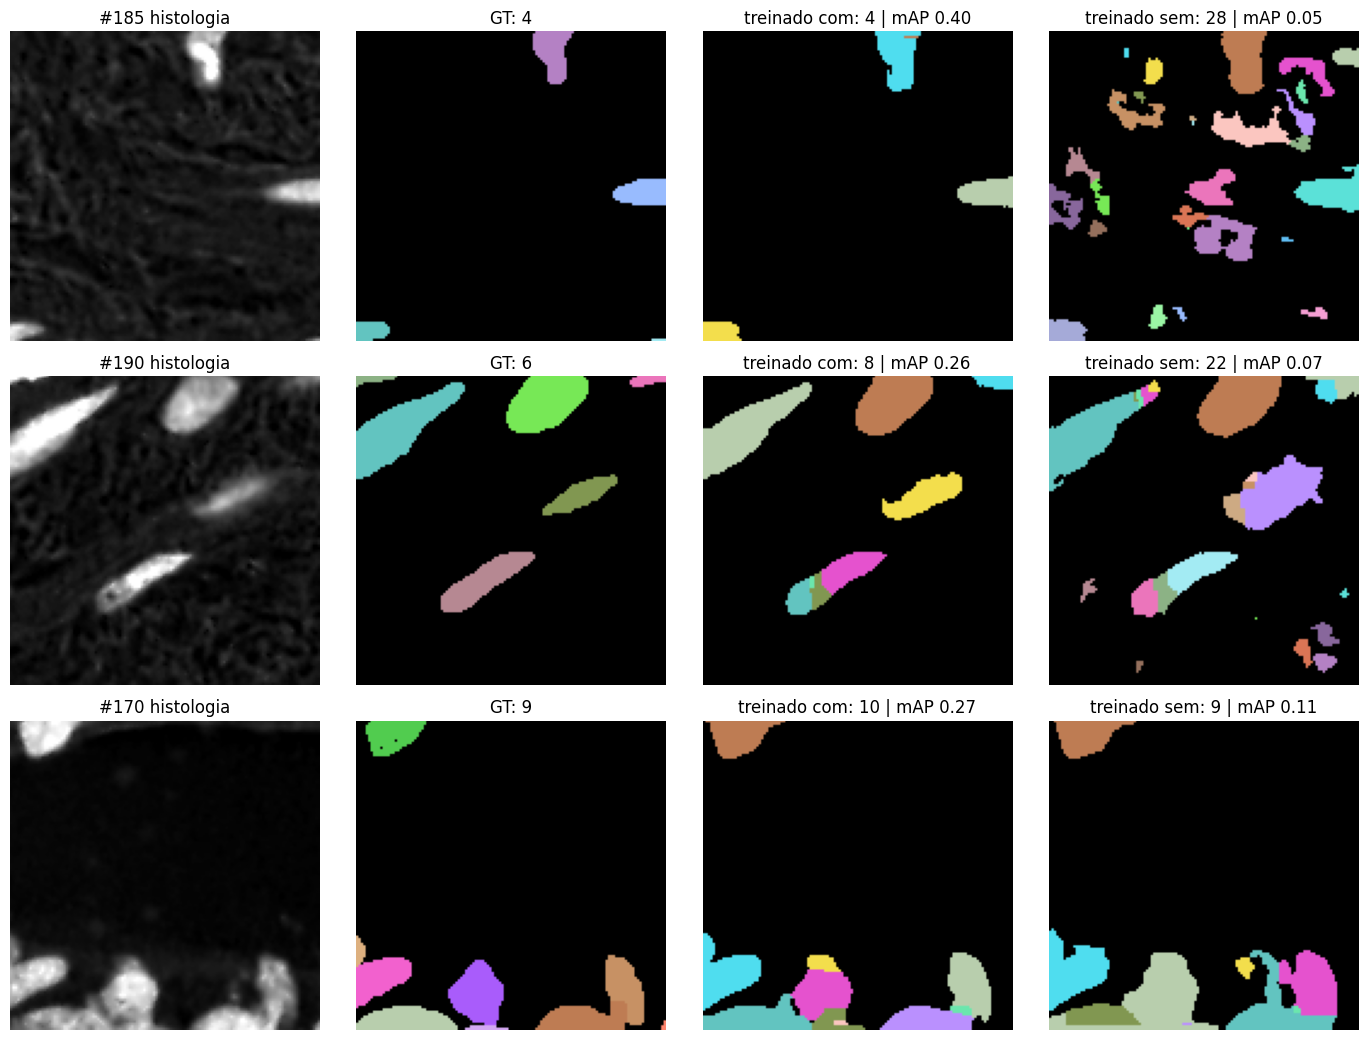

In [93]:
indices_retirada = np.where(sel)[0]
queda = res_watershed["maps"][indices_retirada] - res_sem["maps"][indices_retirada]
exemplos = indices_retirada[np.argsort(queda)[::-1][:3]]

fig, axes = plt.subplots(len(exemplos), 4, figsize=(14, 3.5 * len(exemplos)))
for ax, k in zip(axes, exemplos):
    imagem, gt = teste_real.amostra(k)
    ax[0].imshow(imagem, cmap="gray", vmin=0, vmax=1)
    ax[0].set_title(f"#{k} {MODALIDADE_RETIRADA}")
    ax[1].imshow(colorir_instancias(gt))
    ax[1].set_title(f"GT: {n_objetos(gt)}")
    for a, (modelo, res, titulo) in zip(ax[2:], [(modelo_3c, res_watershed, "treinado com"), (modelo_sem, res_sem, "treinado sem")]):
        pred = decodificar_watershed(prever_classes(modelo, imagem))
        a.imshow(colorir_instancias(pred))
        a.set_title(f"{titulo}: {n_objetos(pred)} | mAP {res['maps'][k]:.2f}")
for ax in axes.ravel():
    ax.axis("off")
plt.tight_layout()
plt.show()

**Leitura.** A coluna "queda" nas modalidades de controle deve ficar perto de zero — se não ficar, a diferença entre os modelos é variância de treino e não mudança de modalidade, e a queda em histologia tem que ser lida descontando isso. Em histologia, a queda mede o quanto a rede aprendeu textura específica da modalidade em vez de "objeto claro sobre fundo escuro": a inversão de polaridade em `para_cinza` já deixou a histologia com a mesma polaridade da fluorescência, então o que sobra de diferença é textura interna do núcleo, contraste com o citoplasma e a densidade de núcleos encostados, típica de tecido. Onde a queda aparece na tabela de AP por limiar diz o tipo de erro: queda já em IoU 0,50 é núcleo perdido ou fundido (foreground e marcadores errados); queda só nos limiares altos é contorno impreciso, com os núcleos ainda encontrados.